In [1]:
# =========================
# Standard library imports
# =========================
import sys
import os
import io
import gzip
from pathlib import Path
import math
import json
import pickle
import logging
import random
import subprocess
import warnings
import collections
import itertools
import re
from IPython.display import display

warnings.filterwarnings("ignore")


# =========================
# Numeric / stats
# =========================
import numpy as np
import pandas as pd
from scipy import sparse
from scipy import stats
from scipy.stats import rankdata
from scipy import __version__ as scipy_version


# =========================
# Plotting / visualization
# =========================
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, FormatStrFormatter, MaxNLocator
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
import seaborn as sns


# =========================
# scikit-learn
# =========================
from sklearn import model_selection, metrics
from sklearn.model_selection import (
    train_test_split,
    GroupShuffleSplit,
    KFold,
    GroupKFold,
    cross_val_score,
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neighbors import LocalOutlierFactor
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
)
from sklearn import __version__ as sklearn_version


# =========================
# Optimization / AutoML
# =========================
import optuna


# =========================
# LightGBM
# =========================
try:
    import lightgbm as lgb
    from lightgbm import LGBMRegressor
    _HAS_LGBM = True
except Exception as e:
    _HAS_LGBM = False
    raise RuntimeError(
        "LightGBM not installed. Please install it with `pip install lightgbm`."
    ) from e


# =========================
# RNA structure (ViennaRNA)
# =========================
import RNA


# =========================
# UpSet plots
# =========================
try:
    from upsetplot import UpSet, from_memberships
except Exception:
    _ = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "upsetplot"],
        check=False,
    )
    from upsetplot import UpSet, from_memberships


# =========================
# Model explanation
# =========================
import shap


# =========================
# User-provided utilities
# =========================
import sylib  


# =========================
# Version info
# =========================
print(f"python    = {sys.version_info[0]}.{sys.version_info[1]}.{sys.version_info[2]}")
print(f"pandas    = {pd.__version__}")
print(f"numpy     = {np.__version__}")
print(f"scipy     = {scipy_version}")
print(f"optuna    = {optuna.__version__}")
print(f"sklearn   = {sklearn_version}")
print(f"ViennaRNA = {RNA.__version__}")
print(f"lightgbm  = {lgb.__version__}")
print(f"sylib     = {sylib.__version__}")


# =========================
# Progress bar & logging
# =========================
# progress bar from sylib
progress_bar = sylib.utils.ProgressBar()

# reset handlers then configure logging
logging.root.handlers = []
stream_handler = logging.StreamHandler(sys.stderr)
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)8s: %(message)s",
    handlers=[stream_handler],
)
logger = logging.getLogger(__name__)

# make matplotlib quieter
logging.getLogger("matplotlib").setLevel(logging.WARNING)

python    = 3.11.15
pandas    = 2.3.3
numpy     = 2.4.6
scipy     = 1.17.1
optuna    = 4.9.0
sklearn   = 1.9.0
ViennaRNA = 2.7.2
lightgbm  = 4.6.0
sylib     = 0.3.0.dev0+ae18bb2


In [2]:
# ============================================
# Global plotting configuration
# ============================================

_PLOT_CFG = {
    "fig_w": 6.0,
    "fig_h": 6.0,
    "dpi": 300,
}


SPECIES_INFO = {
    "AT21": {
        "label": "AT",
        "short": "AT21",
        "color": "#664D0AFF",
        "marker": "o",
    },
    "NB21": {
        "label": "NB",
        "short": "NB21",
        "color": "#7e3131",
        "marker": "^",
    },
    "OS21": {
        "label": "OS",
        "short": "OS21",
        "color": "#13563f",
        "marker": "s",
    },
}

def set_plot_style(
    *,
    base_fontsize=10,
    title_fontsize=12,
    label_fontsize=10,
    tick_fontsize=9,
    legend_fontsize=10,
    dpi=300,
    axes_linewidth=1.2,
    spines_top=True,
    spines_right=True,
    tick_size_major=6,
    tick_dir="out",
    grid=False,
    fig_w=6.0,
    fig_h=6.0,
):
    sns.set_style("ticks")

    mpl.rcParams.update({
        "font.family": "DejaVu Sans",
        "font.size": base_fontsize,

        "axes.titlesize": title_fontsize,
        "axes.labelsize": label_fontsize,

        "xtick.labelsize": tick_fontsize,
        "ytick.labelsize": tick_fontsize,

        "legend.fontsize": legend_fontsize,

        "figure.dpi": dpi,
        "savefig.dpi": dpi,

        "axes.linewidth": axes_linewidth,
        "axes.spines.top": spines_top,
        "axes.spines.right": spines_right,
        "axes.grid": grid,
        "axes.axisbelow": True,

        "xtick.major.size": tick_size_major,
        "ytick.major.size": tick_size_major,
        "xtick.direction": tick_dir,
        "ytick.direction": tick_dir,

        "legend.frameon": False,

        "savefig.bbox": "tight",
        "savefig.transparent": False,
        "figure.autolayout": False,
    })

    _PLOT_CFG.update({
        "fig_w": fig_w,
        "fig_h": fig_h,
        "dpi": dpi,
    })


def make_fig(w=None, h=None, dpi=None):
    W = float(w) if w is not None else _PLOT_CFG["fig_w"]
    H = float(h) if h is not None else _PLOT_CFG["fig_h"]
    D = dpi if dpi is not None else _PLOT_CFG["dpi"]

    fig, ax = plt.subplots(
        figsize=(W, H),
        dpi=D,
    )

    return fig, ax


def _compact_formatter():
    def _fmt(x, _pos=None):
        axx = abs(x)

        if axx >= 1e9:
            s = f"{x / 1e9:.1f}B"
        elif axx >= 1e6:
            s = f"{x / 1e6:.1f}M"
        elif axx >= 1e3:
            s = f"{x / 1e3:.1f}k"
        else:
            s = f"{x:.2g}"

        return (
            s.replace(".0B", "B")
             .replace(".0M", "M")
             .replace(".0k", "k")
        )

    return FuncFormatter(_fmt)


def format_axis(
    ax,
    *,
    xlabel=None,
    ylabel=None,
    compact_ticks=(),
):
    if xlabel is not None:
        ax.set_xlabel(xlabel)

    if ylabel is not None:
        ax.set_ylabel(ylabel)

    fmt = _compact_formatter()

    if "x" in compact_ticks:
        ax.xaxis.set_major_formatter(fmt)

    if "y" in compact_ticks:
        ax.yaxis.set_major_formatter(fmt)

    return ax


# ============================================
# Joint scatter with KDE marginals
# ============================================

def safe_pearsonr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.nan, np.nan

    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan

    return stats.pearsonr(x, y)


def safe_spearmanr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.nan, np.nan

    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan

    return stats.spearmanr(x, y)

def _kde_1d(values, lo, hi, num=256):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    grid = np.linspace(lo, hi, num)

    if len(values) < 2:
        return grid, np.zeros_like(grid)

    try:
        kde = stats.gaussian_kde(values)
        dens = kde(grid)
        dens /= dens.max() if dens.max() > 0 else 1
        return grid, dens

    except Exception:
        return grid, np.zeros_like(grid)


def joint_scatter(
    x,
    y,
    *,
    color=None,
    point_size=18,
    alpha=0.65,
    show_identity=True,
    show_regression=True,
    annotate=True,
    annotate_spearman=True,
    xlabel=None,
    ylabel=None,
    title=None,
    figsize=None,
    w=None,
    h=None,
    dpi=None,
    annotate_fontsize=14,
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    n = len(x)

    if figsize is not None:
        FW, FH = figsize
    else:
        FW = float(w) if w is not None else _PLOT_CFG["fig_w"]
        FH = float(h) if h is not None else _PLOT_CFG["fig_h"]

    fig = plt.figure(
        figsize=(FW, FH),
        dpi=(dpi or _PLOT_CFG["dpi"]),
    )

    gs = GridSpec(
        2,
        2,
        width_ratios=(4, 1),
        height_ratios=(1, 4),
        hspace=0.05,
        wspace=0.05,
    )

    ax_top = fig.add_subplot(gs[0, 0])
    ax_joint = fig.add_subplot(gs[1, 0], sharex=ax_top)
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_joint)

    ax_joint.scatter(
        x,
        y,
        s=point_size,
        alpha=alpha,
        edgecolor="none",
        color=color,
    )

    lo = float(np.nanmin([x.min(), y.min()]))
    hi = float(np.nanmax([x.max(), y.max()]))

    pad = 0.05 * (hi - lo if hi > lo else 1.0)

    lo -= pad
    hi += pad

    ax_joint.set_xlim(lo, hi)
    ax_joint.set_ylim(lo, hi)

    if show_identity:
        ax_joint.plot(
            [lo, hi],
            [lo, hi],
            ls="--",
            lw=1.2,
            color="0.65",
            zorder=1,
        )

    if show_regression and n >= 2 and np.std(x) > 0 and np.std(y) > 0:
        slope, intercept = np.polyfit(x, y, 1)

        ax_joint.plot(
            [lo, hi],
            slope * np.array([lo, hi]) + intercept,
            color="black",
            lw=1.5,
            zorder=2,
        )

    format_axis(
        ax_joint,
        xlabel=xlabel,
        ylabel=ylabel,
        compact_ticks=(),
    )

    if title:
        ax_joint.set_title(title)

    if annotate and n >= 2 and np.std(x) > 0 and np.std(y) > 0:
        rp, _ = safe_pearsonr(x, y)
        rs, _ = safe_spearmanr(x, y)

        txt = rf"$r_p = {rp:.2f}$"

        if annotate_spearman:
            txt += "\n" + rf"$r_s = {rs:.2f}$"

        txt += f"\n$n = {n}$"

        ax_joint.text(
            0.04,
            0.96,
            txt,
            transform=ax_joint.transAxes,
            ha="left",
            va="top",
            fontsize=annotate_fontsize,
        )

    gx, dx = _kde_1d(x, lo, hi)
    gy, dy = _kde_1d(y, lo, hi)

    ax_top.plot(gx, dx, lw=2, color=color)
    ax_top.axis("off")

    ax_right.plot(dy, gy, lw=2, color=color)
    ax_right.axis("off")

    plt.tight_layout()

    return fig, (ax_joint, ax_top, ax_right)


set_plot_style()

# ============================================
# Plot helper functions
# ============================================

def species_palette():
    return [
        SPECIES_INFO["AT21"]["color"],
        SPECIES_INFO["NB21"]["color"],
        SPECIES_INFO["OS21"]["color"],
    ]


def outside_legend(
    ax,
    *,
    title="Species",
    n_items=3,
    x=1.02,
    y=1.00,
):
    handles, labels = ax.get_legend_handles_labels()

    ax.legend(
        handles[:n_items],
        labels[:n_items],
        title=title,
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(x, y),
        borderaxespad=0,
    )

    return ax

In [3]:
# ============================================
# Prepare locked p90 candidate analysis data
# ============================================

RESULT_DIR = Path("/mnt/d/Ibnu/Programming/data/regression/results/lgbm")
SPECIES = ["AT21", "NB21", "OS21"]

candidate_all_df = pd.read_csv(
    RESULT_DIR / "lgbm.species_specific_candidate_table.importance_p90.sss_p90.tsv.gz",
    sep="\t",
)

candidate_selected_df = candidate_all_df.loc[candidate_all_df["Selected"]].copy().reset_index(drop=True)
candidate_features = sorted(candidate_selected_df["Feature"].unique())

feature_metadata_df = (
    candidate_selected_df[["Feature", "Region", "Feature_type"]]
    .drop_duplicates()
    .sort_values("Feature")
    .reset_index(drop=True)
)

assert feature_metadata_df["Feature"].is_unique
assert set(feature_metadata_df["Feature"]) == set(candidate_features)

feature_meta_lookup = feature_metadata_df.set_index("Feature")

# --------------------------------------------
# Raw + model-space data
# --------------------------------------------

lgbm_data = {}
raw_rows, model_rows = [], []

for species_key in SPECIES:
    species = SPECIES_INFO[species_key]["label"]

    with gzip.open(RESULT_DIR / f"{species_key}.lgbm.data_bundle.pkl.gz", "rb") as f:
        bundle = pickle.load(f)

    assert bundle["species"] == species_key
    assert not (set(candidate_features) - set(bundle["feature_names"]))

    metadata = pd.concat([bundle["train_metadata"], bundle["test_metadata"]])
    x_raw = pd.concat([bundle["x_train_raw"], bundle["x_test_raw"]])[candidate_features]
    x_model = pd.concat([bundle["x_train_model"], bundle["x_test_model"]])[candidate_features]

    assert metadata.index.equals(x_raw.index) and metadata.index.equals(x_model.index)

    raw_df = pd.concat([metadata, x_raw], axis=1)
    model_df = pd.concat([metadata, x_model], axis=1)

    for df in (raw_df, model_df):
        df.insert(0, "Species", species)
        df.insert(1, "Species_key", species_key)

    raw_rows.append(raw_df)
    model_rows.append(model_df)
    lgbm_data[species_key] = bundle

candidate_master_df = pd.concat(raw_rows, ignore_index=True)
candidate_model_master_df = pd.concat(model_rows, ignore_index=True)

# --------------------------------------------
# Long-format raw candidate data
# --------------------------------------------

id_cols = [
    "Species", "Species_key", "var_id", "trans_id", "gene_id",
    "dataset", "observed_raw", "observed_model", "predicted_model",
]

candidate_long_df = (
    candidate_master_df
    .melt(id_vars=id_cols, value_vars=candidate_features,
          var_name="Feature", value_name="Value")
    .merge(feature_metadata_df, on="Feature", how="left", validate="many_to_one")
)

# --------------------------------------------
# Sanity check + summary
# --------------------------------------------

transform_check_df = pd.DataFrame([
    {
        "Species": SPECIES_INFO[k]["label"],
        "Mean_abs_feature_mean": candidate_model_master_df.loc[
            candidate_model_master_df["Species"] == SPECIES_INFO[k]["label"], candidate_features
        ].mean().abs().mean(),
        "Mean_feature_SD": candidate_model_master_df.loc[
            candidate_model_master_df["Species"] == SPECIES_INFO[k]["label"], candidate_features
        ].std().mean(),
        "Missing_values": int(candidate_model_master_df.loc[
            candidate_model_master_df["Species"] == SPECIES_INFO[k]["label"], candidate_features
        ].isna().sum().sum()),
    }
    for k in SPECIES
])

selected_count_df = (
    candidate_selected_df.groupby("Species")
    .size()
    .reindex(["AT", "NB", "OS"])
    .rename("N_selected")
    .reset_index()
)

print("Locked p90 candidate analysis")
print("-----------------------------")
print("Selected rows   :", len(candidate_selected_df))
print("Unique features :", len(candidate_features))
print("Raw shape       :", candidate_master_df.shape)
print("Model shape     :", candidate_model_master_df.shape)
print("Long shape      :", candidate_long_df.shape)

display(selected_count_df)
display(transform_check_df)

Locked p90 candidate analysis
-----------------------------
Selected rows   : 70
Unique features : 61
Raw shape       : (18059, 70)
Model shape     : (18059, 70)
Long shape      : (1101599, 13)


,Species,N_selected
0,AT,19
1,NB,28
2,OS,23


,Species,Mean_abs_feature_mean,Mean_feature_SD,Missing_values
0,AT,0.004279,0.998224,0
1,NB,0.004563,0.999097,0
2,OS,0.003555,1.002359,0


In [5]:
# ============================================
# Joint FI + SSS selected feature inventory
# Ranked by FI within selected set
# ============================================

selected_feature_df = (
    candidate_selected_df[
        ["Species", "Feature", "Region", "Feature_type",
         "Importance_normalized", "Importance_percentile",
         "SSS", "SSS_percentile"]
    ]
    .sort_values(["Species", "Importance_normalized"], ascending=[True, False])
    .reset_index(drop=True)
)

selected_feature_df["FI_rank"] = (
    selected_feature_df.groupby("Species").cumcount() + 1
)

selected_feature_df = selected_feature_df[
    ["Species", "FI_rank", "Feature", "Region", "Feature_type",
     "Importance_normalized", "Importance_percentile",
     "SSS", "SSS_percentile"]
]

print("Locked FI + SSS p90 features")
print("----------------------------")

for species in ["AT", "NB", "OS"]:
    temp = selected_feature_df.query("Species == @species").reset_index(drop=True)
    print(f"\n{species}: n = {len(temp)}")
    display(temp)

Locked FI + SSS p90 features
----------------------------

AT: n = 19


,Species,FI_rank,Feature,Region,Feature_type,Importance_normalized,Importance_percentile,SSS,SSS_percentile
0,AT,1,5'UTR.CUU-freq,5'UTR,Nucleotide_kmer_freq,0.007632,1.000000,0.004324,0.928731
1,AT,2,5'UTR.S-freq,5'UTR,Nucleotide_kmer_freq,0.007105,0.995546,0.005207,0.966592
2,AT,3,5'UTR.U-freq,5'UTR,Nucleotide_kmer_freq,0.006842,0.993318,0.006238,0.979955
3,AT,4,5'UTR.MFE,5'UTR,RNA_structure_MFE,0.006579,0.991091,0.004869,0.953229
4,AT,5,mRNA.AUC-freq,mRNA,Nucleotide_kmer_freq,0.006316,0.986637,0.005450,0.968820
5,AT,6,5'UTR.G-freq,5'UTR,Nucleotide_kmer_freq,0.006316,0.986637,0.004291,0.924276
6,AT,7,3'UTR.GAU-freq,3'UTR,Nucleotide_kmer_freq,0.005789,0.978842,0.005705,0.971047
7,AT,8,5'UTR.Length,5'UTR,Length,0.005526,0.974388,0.010997,0.997773
8,AT,9,3'UTR.UAG-freq,3'UTR,Nucleotide_kmer_freq,0.005526,0.974388,0.006610,0.986637
9,AT,10,mRNA.MFE,mRNA,RNA_structure_MFE,0.005000,0.958797,0.008363,0.993318



NB: n = 28


,Species,FI_rank,Feature,Region,Feature_type,Importance_normalized,Importance_percentile,SSS,SSS_percentile
0,NB,1,mRNA.Length,mRNA,Length,0.020753,1.000000,0.019007,1.000000
1,NB,2,mRNA.MFE,mRNA,RNA_structure_MFE,0.013014,0.997773,0.013132,0.997773
2,NB,3,5'UTR.MFE,5'UTR,RNA_structure_MFE,0.010200,0.995546,0.007771,0.991091
3,NB,4,5'UTR.Length,5'UTR,Length,0.009145,0.993318,0.007673,0.988864
4,NB,5,3'UTR.AG-freq,3'UTR,Nucleotide_kmer_freq,0.008794,0.991091,0.009082,0.995546
5,NB,6,5'UTR.UG-freq,5'UTR,Nucleotide_kmer_freq,0.008442,0.988864,0.008929,0.993318
6,NB,7,5'UTR.CUC-freq,5'UTR,Nucleotide_kmer_freq,0.008090,0.986637,0.004804,0.944321
7,NB,8,CDS.Length,CDS,Length,0.007738,0.984410,0.005380,0.964365
8,NB,9,5'UTR.UAU-freq,5'UTR,Nucleotide_kmer_freq,0.007387,0.979955,0.005869,0.975501
9,NB,10,5'UTR.CU-freq,5'UTR,Nucleotide_kmer_freq,0.007387,0.979955,0.004173,0.919822



OS: n = 23


,Species,FI_rank,Feature,Region,Feature_type,Importance_normalized,Importance_percentile,SSS,SSS_percentile
0,OS,1,5'UTR.Length,5'UTR,Length,0.015911,1.000000,0.012394,1.000000
1,OS,2,mRNA.Length,mRNA,Length,0.011874,0.997773,0.011902,0.997773
2,OS,3,3'UTR.Length,3'UTR,Length,0.009736,0.995546,0.009053,0.993318
3,OS,4,5'UTR.UC-freq,5'UTR,Nucleotide_kmer_freq,0.008549,0.993318,0.008327,0.991091
4,OS,5,CDS.Length,CDS,Length,0.008074,0.991091,0.005716,0.982183
5,OS,6,5'UTR.CCC-freq,5'UTR,Nucleotide_kmer_freq,0.006887,0.987751,0.005413,0.977728
6,OS,7,mRNA.UC-freq,mRNA,Nucleotide_kmer_freq,0.006412,0.984410,0.005394,0.975501
7,OS,8,5'UTR.CC-freq,5'UTR,Nucleotide_kmer_freq,0.006174,0.981069,0.004200,0.933185
8,OS,9,mRNA.Y-freq,mRNA,Nucleotide_kmer_freq,0.005937,0.977728,0.004440,0.942094
9,OS,10,5'UTR.CCG-freq,5'UTR,Nucleotide_kmer_freq,0.005462,0.963252,0.005614,0.979955


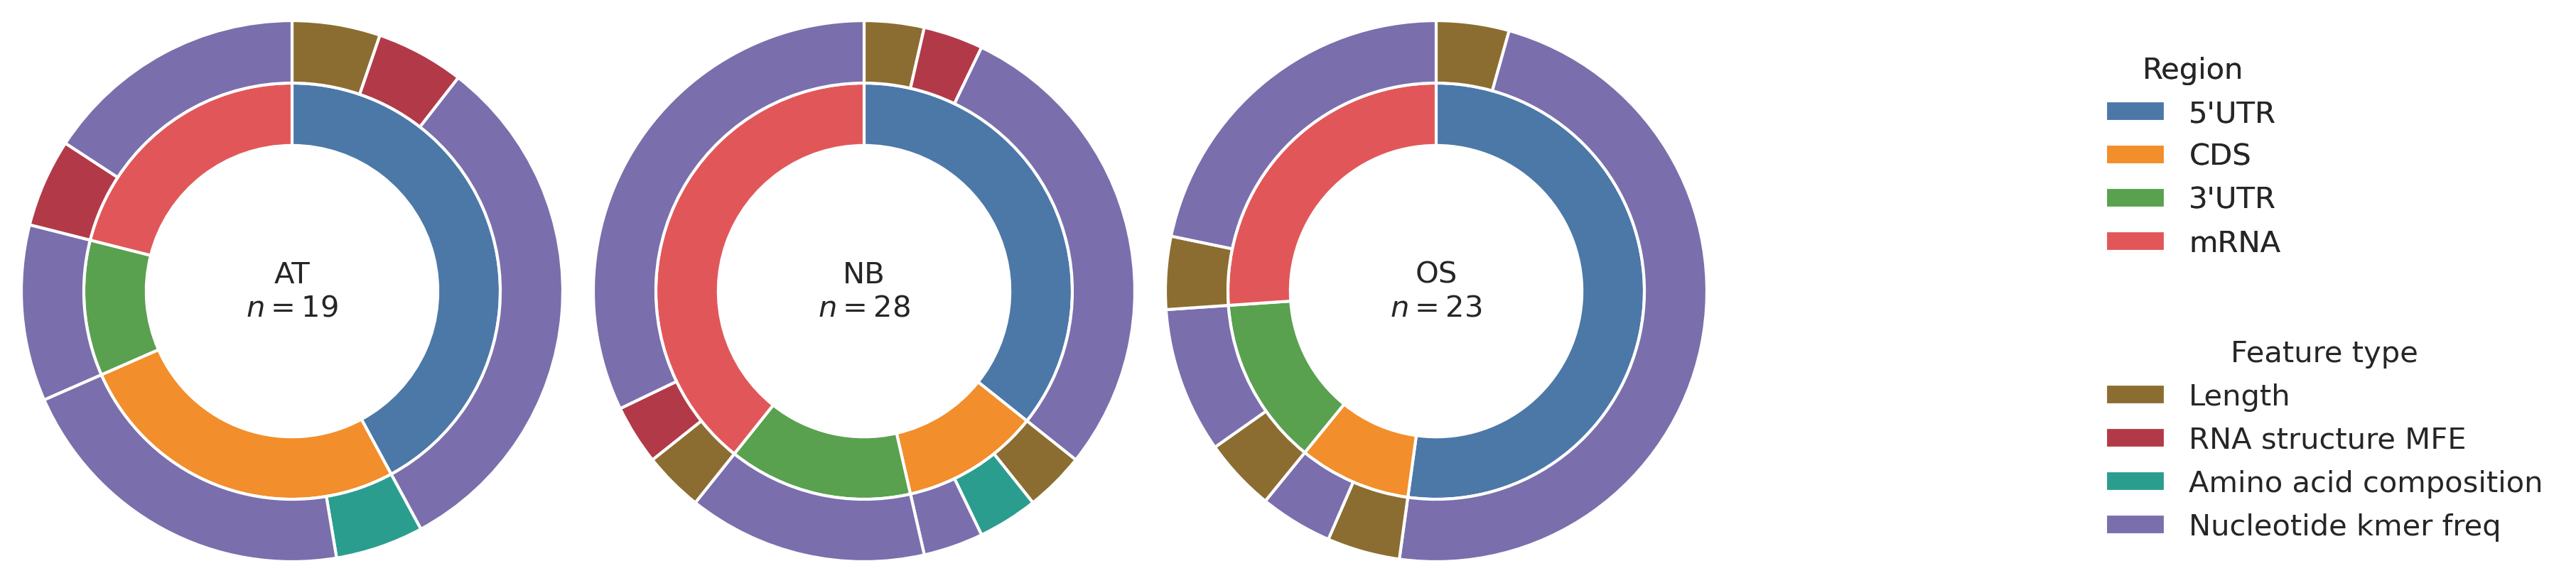

In [6]:
# ============================================
# Joint-selected candidate composition
# Region + feature type
# ============================================

from matplotlib.patches import Patch

region_order = ["5'UTR", "CDS", "3'UTR", "mRNA"]
feature_type_order = ["Length", "RNA_structure_MFE", "Amino_acid_composition", "Nucleotide_kmer_freq"]

region_colors = {"5'UTR": "#4C78A8", "CDS": "#F28E2B", "3'UTR": "#59A14F", "mRNA": "#E15759"}
feature_type_colors = {
    "Length": "#8C6D31", "RNA_structure_MFE": "#B23A48",
    "Amino_acid_composition": "#2A9D8F", "Nucleotide_kmer_freq": "#7A6FAC",
}

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5), dpi=_PLOT_CFG["dpi"])

for ax, species_key in zip(axes, SPECIES):
    species = SPECIES_INFO[species_key]["label"]
    df = candidate_selected_df.query("Species == @species")

    region_counts = df["Region"].value_counts().reindex(region_order, fill_value=0)
    outer_counts, outer_colors = [], []

    for region in region_order:
        counts = df.loc[df["Region"] == region, "Feature_type"].value_counts()
        for feature_type in feature_type_order:
            n = counts.get(feature_type, 0)
            if n:
                outer_counts.append(n)
                outer_colors.append(feature_type_colors[feature_type])

    ax.pie(
        region_counts, radius=1.0, colors=[region_colors[x] for x in region_order],
        startangle=90, counterclock=False,
        wedgeprops={"width": 0.30, "edgecolor": "white"},
    )

    ax.pie(
        outer_counts, radius=1.30, colors=outer_colors,
        startangle=90, counterclock=False,
        wedgeprops={"width": 0.30, "edgecolor": "white"},
    )

    ax.text(0, 0, f"{species}\n$n={len(df)}$", ha="center", va="center")

region_handles = [Patch(facecolor=region_colors[x], label=x) for x in region_order]
type_handles = [Patch(facecolor=feature_type_colors[x], label=x.replace("_", " ")) for x in feature_type_order]

leg = fig.legend(region_handles, region_order, title="Region",
                 loc="center left", bbox_to_anchor=(0.98, 0.68), frameon=False)
fig.add_artist(leg)

fig.legend(type_handles, [x.replace("_", " ") for x in feature_type_order],
           title="Feature type", loc="center left",
           bbox_to_anchor=(0.98, 0.30), frameon=False)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

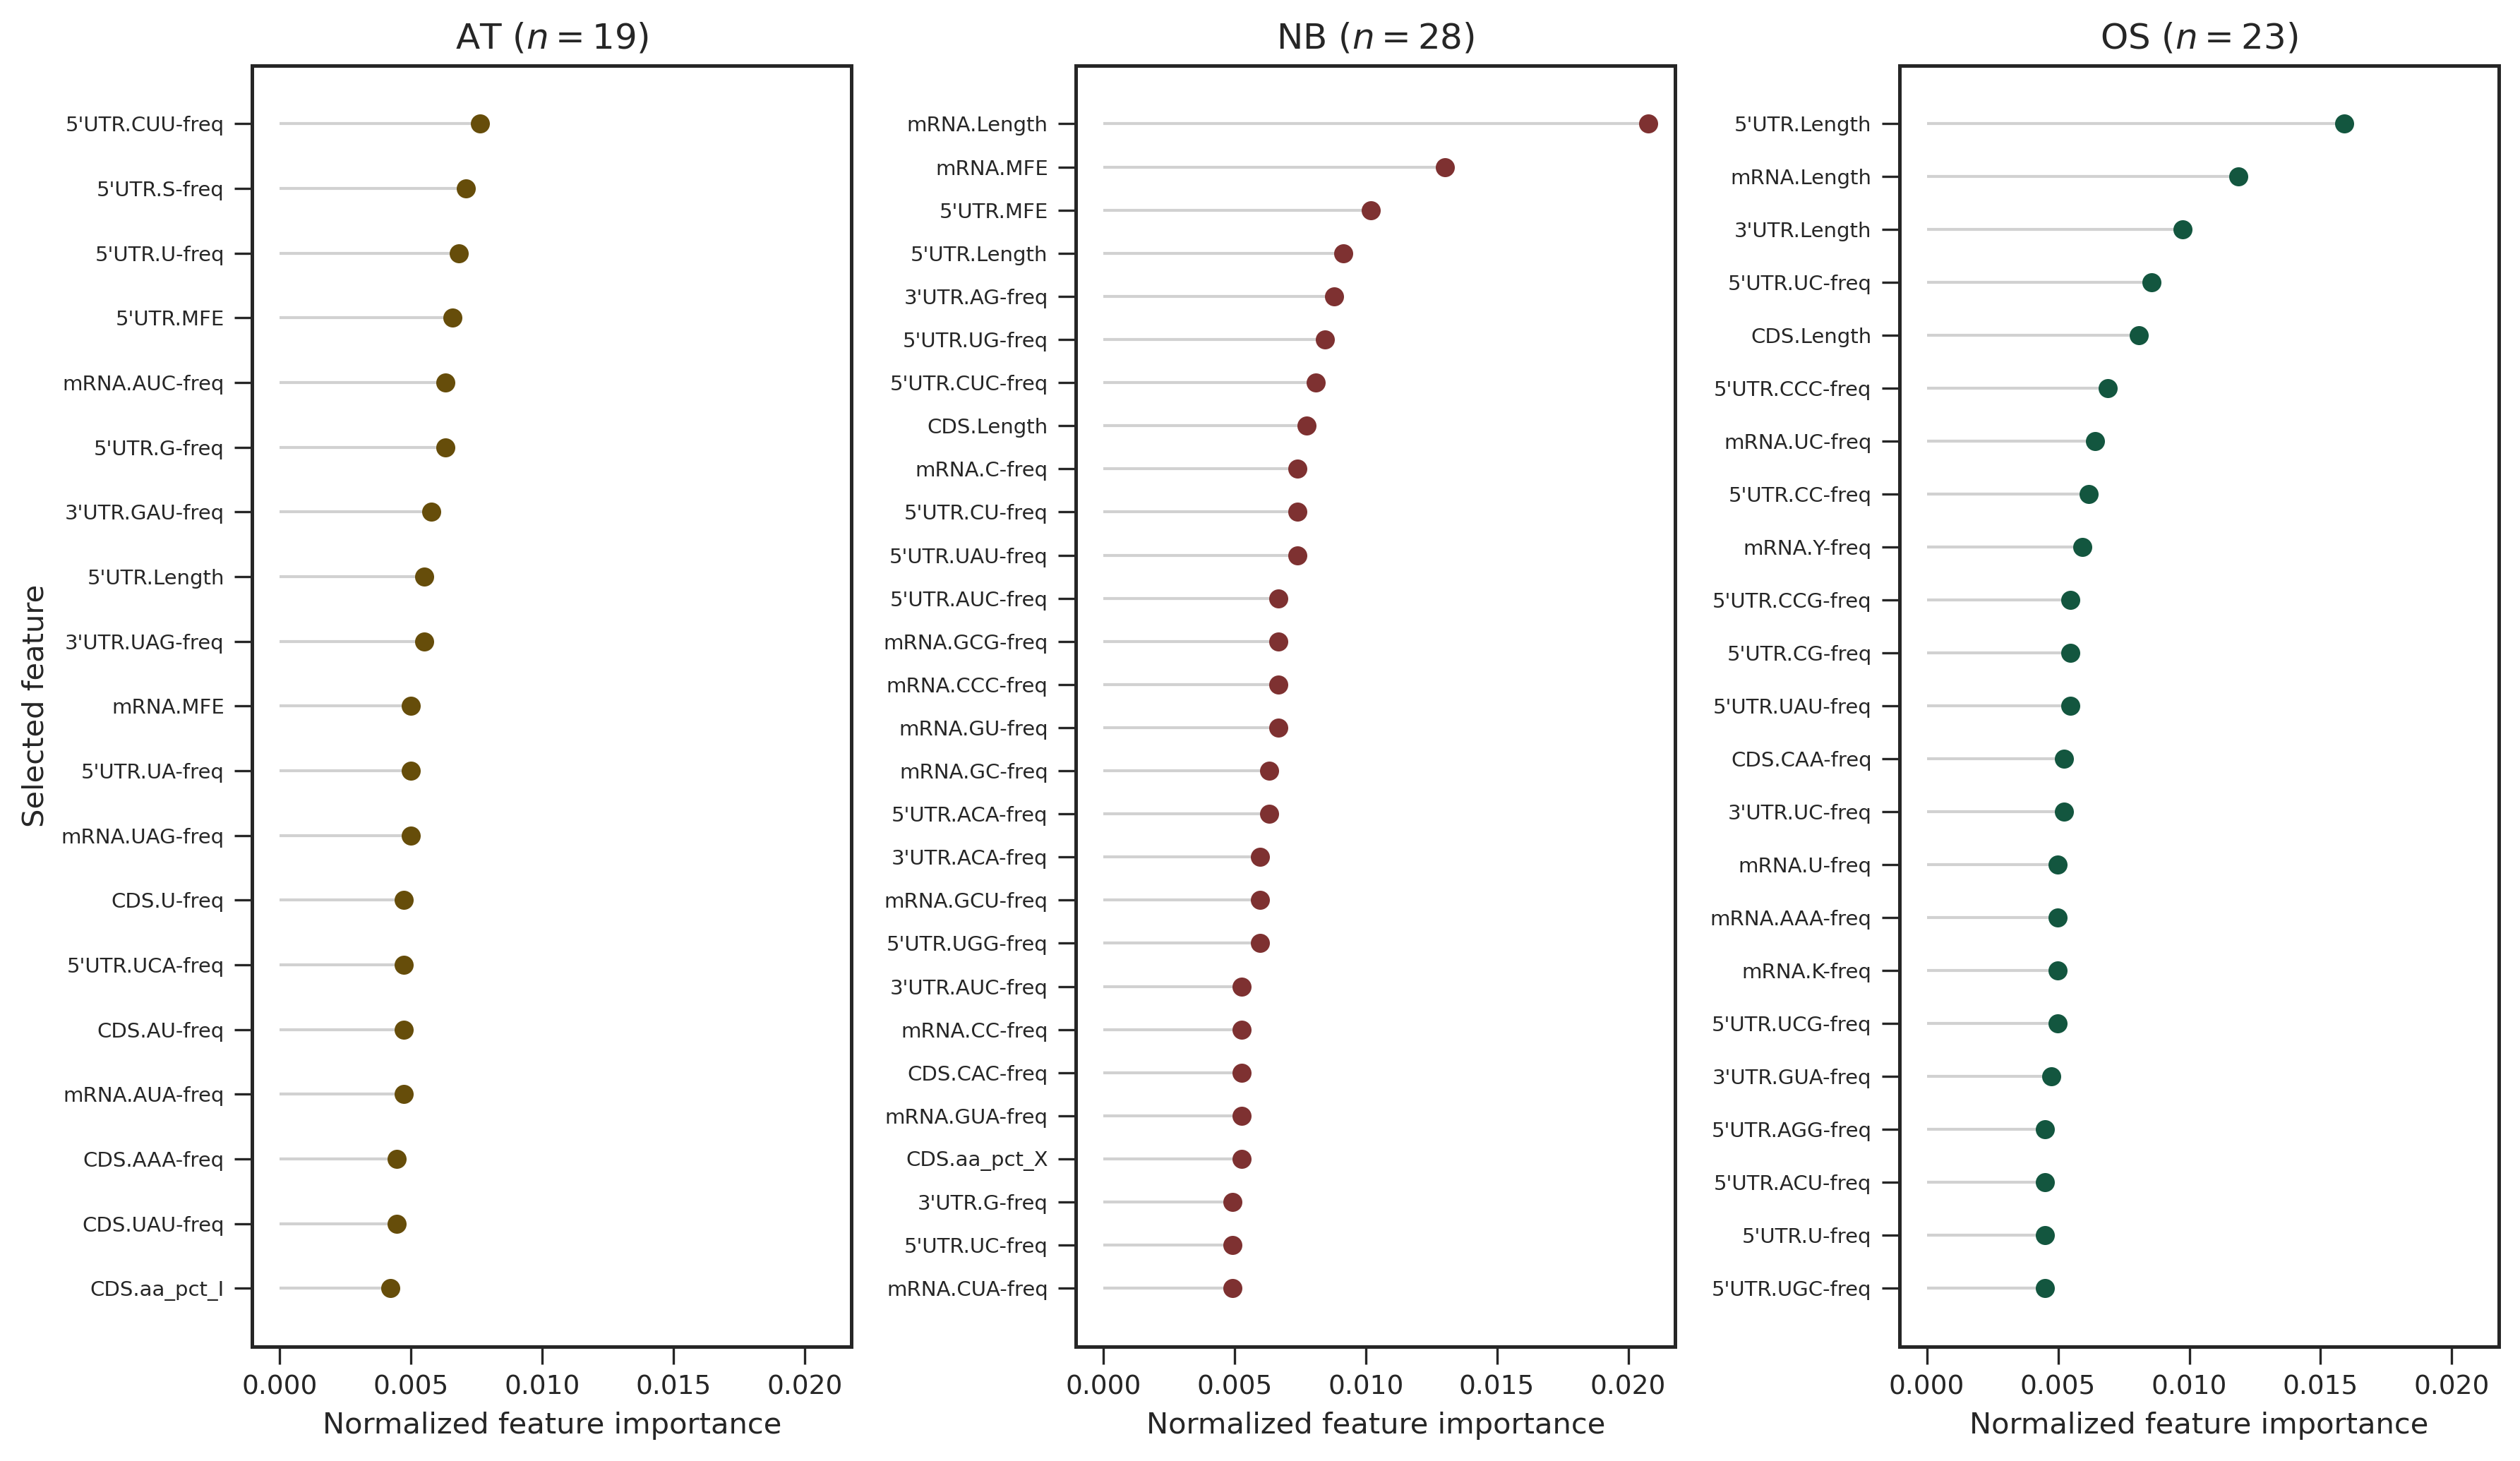

In [7]:
# ============================================
# Joint-selected features by species
# Ranked normalized FI
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(12, 7), dpi=_PLOT_CFG["dpi"], sharex=True)

for ax, species_key in zip(axes, SPECIES):
    species, color = SPECIES_INFO[species_key]["label"], SPECIES_INFO[species_key]["color"]

    temp = (
        selected_feature_df.query("Species == @species")
        .sort_values("Importance_normalized", ascending=True)
        .reset_index(drop=True)
    )

    y = np.arange(len(temp))
    ax.hlines(y, 0, temp["Importance_normalized"], color="0.82", lw=1)
    ax.scatter(temp["Importance_normalized"], y, s=30, color=color, zorder=3)

    ax.set_yticks(y)
    ax.set_yticklabels(temp["Feature"], fontsize=7)
    ax.set_title(f"{species} ($n={len(temp)}$)")

    format_axis(
        ax,
        xlabel="Normalized feature importance",
        ylabel="Selected feature" if ax is axes[0] else None,
    )

plt.tight_layout()
plt.show()

In [8]:
# ============================================
# FI-only vs FI + SSS p90 selection
# ============================================

screening_df = pd.read_csv(RESULT_DIR / "lgbm.screening_feature_table.tsv.gz", sep="\t")
CUTOFF = 0.90

fi_only_df = screening_df.loc[
    screening_df["Importance_percentile"] >= CUTOFF
].copy()

fi_sss_df = screening_df.loc[
    (screening_df["Importance_percentile"] >= CUTOFF) &
    (screening_df["SSS_percentile"] >= CUTOFF)
].copy()

rows = []
for species in ["AT", "NB", "OS"]:
    fi_set = set(fi_only_df.loc[fi_only_df["Species"] == species, "Feature"])
    joint_set = set(fi_sss_df.loc[fi_sss_df["Species"] == species, "Feature"])

    rows.append({
        "Species": species,
        "FI_only": len(fi_set),
        "FI_SSS": len(joint_set),
        "Removed_by_SSS": len(fi_set - joint_set),
        "Retained_pct": 100 * len(joint_set) / len(fi_set),
    })

    assert joint_set <= fi_set

fi_comparison_df = pd.DataFrame(rows)

print("FI-only vs FI + SSS p90")
print("------------------------")
display(fi_comparison_df.style.format({"Retained_pct": "{:.1f}"}))

FI-only vs FI + SSS p90
------------------------


,Species,FI_only,FI_SSS,Removed_by_SSS,Retained_pct
0,AT,45,19,26,42.2
1,NB,44,28,16,63.6
2,OS,41,23,18,56.1


In [11]:
# ============================================
# Verify FI + SSS is nested within FI-only
# ============================================

for species in ["AT", "NB", "OS"]:
    fi_set = set(fi_only_df.loc[fi_only_df["Species"] == species, "Feature"])
    joint_set = set(fi_sss_df.loc[fi_sss_df["Species"] == species, "Feature"])

    print(
        f"{species}: "
        f"FI-only={len(fi_set)}, "
        f"FI+SSS={len(joint_set)}, "
        f"joint outside FI={len(joint_set - fi_set)}"
    )

    assert joint_set.issubset(fi_set)

AT: FI-only=45, FI+SSS=19, joint outside FI=0
NB: FI-only=44, FI+SSS=28, joint outside FI=0
OS: FI-only=41, FI+SSS=23, joint outside FI=0


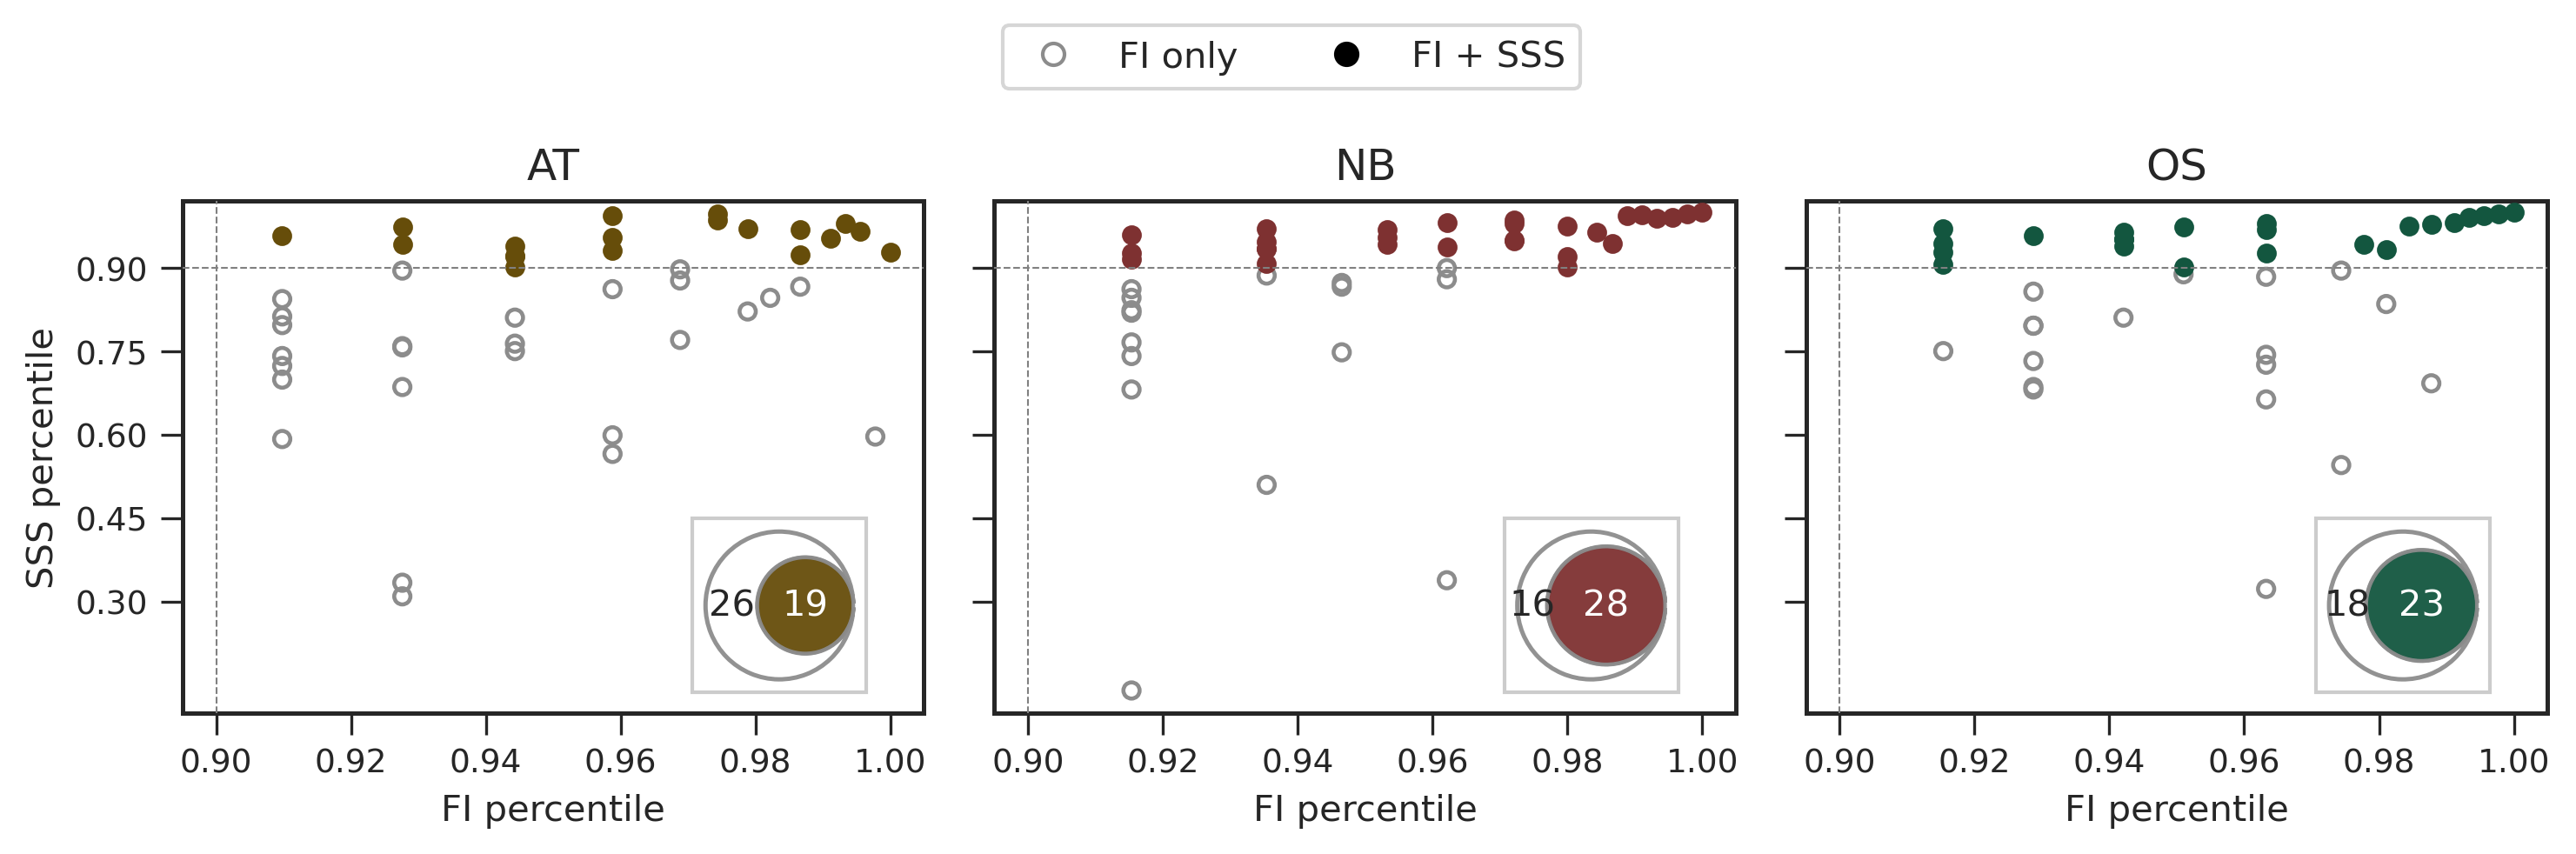

In [25]:
# ============================================
# FI-p90 feature fate after SSS screening
# ============================================

from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib_venn import venn2

fi_fate_df = fi_only_df.copy()
joint_keys = set(zip(fi_sss_df["Species"], fi_sss_df["Feature"]))

fi_fate_df["Selection"] = [
    "FI + SSS" if (s, f) in joint_keys else "FI only"
    for s, f in zip(fi_fate_df["Species"], fi_fate_df["Feature"])
]

fig, axes = plt.subplots(
    1, 3, figsize=(10, 3.2),
    dpi=_PLOT_CFG["dpi"],
    sharex=True, sharey=True,
)

for ax, species_key in zip(axes, SPECIES):
    species = SPECIES_INFO[species_key]["label"]
    color = SPECIES_INFO[species_key]["color"]

    d = fi_fate_df.query("Species == @species")
    keep = d["Selection"].eq("FI + SSS")

    ax.scatter(
        d.loc[~keep, "Importance_percentile"],
        d.loc[~keep, "SSS_percentile"],
        s=20, facecolors="none", edgecolors="0.55",
        lw=1.1, zorder=2,
    )

    ax.scatter(
        d.loc[keep, "Importance_percentile"],
        d.loc[keep, "SSS_percentile"],
        s=20, color=color, zorder=3,
    )

    ax.axhline(CUTOFF, color="0.5", ls="--", lw=0.5, zorder=4)
    ax.axvline(CUTOFF, color="0.5", ls="--", lw=0.5, zorder=4)

    ax.set_xlim(0.895, 1.005)
    ax.set_ylim(0.10, 1.02)
    ax.set_yticks(np.arange(0.30, 1.01, 0.15))
    ax.set_title(species)

    inset = ax.inset_axes([0.66, 0.04, 0.29, 0.34])
    inset.set_facecolor("white")

    v = venn2(
        subsets=(len(d) - keep.sum(), 0, keep.sum()),
        set_labels=("", ""),
        set_colors=("white", color),
        alpha=0.95,
        ax=inset,
    )

    if v.get_patch_by_id("10"):
        v.get_patch_by_id("10").set_facecolor("white")
        v.get_patch_by_id("10").set_edgecolor("0.55")
        v.get_patch_by_id("10").set_linewidth(1.2)

    if v.get_patch_by_id("11"):
        v.get_patch_by_id("11").set_facecolor(color)
        v.get_patch_by_id("11").set_edgecolor("0.55")
        v.get_patch_by_id("11").set_linewidth(1)

    if v.get_patch_by_id("01"):
        v.get_patch_by_id("01").set_alpha(0)

    if v.get_label_by_id("10"):
        v.get_label_by_id("10").set_color("0.15")

    if v.get_label_by_id("11"):
        v.get_label_by_id("11").set_color("white")

    if v.get_label_by_id("01"):
        v.get_label_by_id("01").set_visible(False)

    inset.add_patch(
        Rectangle(
            (0, 0), 1, 1,
            transform=inset.transAxes,
            facecolor="none", edgecolor="0.80",
            linewidth=1, clip_on=False, zorder=10,
        )
    )

    inset.set_xticks([])
    inset.set_yticks([])

    format_axis(
        ax,
        xlabel="FI percentile",
        ylabel="SSS percentile" if ax is axes[0] else None,
    )

legend = [
    Line2D(
        [0], [0], marker="o", ls="None", ms=6,
        markerfacecolor="none", markeredgecolor="0.55",
        label="FI only",
    ),
    Line2D(
        [0], [0], marker="o", ls="None", ms=6,
        markerfacecolor="black", markeredgecolor="black",
        label="FI + SSS",
    ),
]

fig.legend(
    legend,
    [x.get_label() for x in legend],
    loc="upper center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, 1.03),
)

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()

In [20]:
# ============================================
# Verify joint-selected percentile boundaries
# ============================================

check_df = (
    fi_sss_df.groupby("Species")
    .agg(
        N_features=("Feature", "size"),
        Min_FI_percentile=("Importance_percentile", "min"),
        Min_SSS_percentile=("SSS_percentile", "min"),
    )
    .reset_index()
)

display(check_df)

,Species,N_features,Min_FI_percentile,Min_SSS_percentile
0,AT,19,0.909800,0.902004
1,NB,28,0.915367,0.902004
2,OS,23,0.915367,0.902004


In [41]:
# ============================================
# Candidate panel composition
# ============================================

region_summary_df = (
    feature_metadata_df.groupby("Region", as_index=False)
    .agg(n_features=("Feature", "size"))
    .sort_values("n_features", ascending=False)
    .reset_index(drop=True)
)

region_summary_df["Percent"] = 100 * region_summary_df["n_features"] / len(feature_metadata_df)

feature_type_summary_df = (
    feature_metadata_df.groupby("Feature_type", as_index=False)
    .agg(n_features=("Feature", "size"))
    .sort_values("n_features", ascending=False)
    .reset_index(drop=True)
)

feature_type_summary_df["Percent"] = 100 * feature_type_summary_df["n_features"] / len(feature_metadata_df)

region_feature_table_df = pd.crosstab(
    feature_metadata_df["Region"],
    feature_metadata_df["Feature_type"],
)

candidate_panel_df = (
    feature_metadata_df
    .sort_values(["Region", "Feature_type", "Feature"])
    .reset_index(drop=True)
)

print("Candidate features:", len(candidate_panel_df))

print("\nRegion")
display(region_summary_df)

print("\nFeature type")
display(feature_type_summary_df)

print("\nRegion × Feature type")
display(region_feature_table_df)

print("\nCandidate panel")
display(candidate_panel_df)

Candidate features: 61

Region


,Region,n_features,Percent
0,5'UTR,24,39.344262
1,mRNA,19,31.147541
2,3'UTR,9,14.754098
3,CDS,9,14.754098



Feature type


,Feature_type,n_features,Percent
0,Nucleotide_kmer_freq,53,86.885246
1,Length,4,6.557377
2,Amino_acid_composition,2,3.278689
3,RNA_structure_MFE,2,3.278689



Region × Feature type


Feature_type,Amino_acid_composition,Length,Nucleotide_kmer_freq,RNA_structure_MFE
Region,,,,
3'UTR,0,1,8,0
5'UTR,0,1,22,1
CDS,2,1,6,0
mRNA,0,1,17,1



Candidate panel


,Feature,Region,Feature_type
0,3'UTR.Length,3'UTR,Length
1,3'UTR.ACA-freq,3'UTR,Nucleotide_kmer_freq
2,3'UTR.AG-freq,3'UTR,Nucleotide_kmer_freq
3,3'UTR.AUC-freq,3'UTR,Nucleotide_kmer_freq
4,3'UTR.G-freq,3'UTR,Nucleotide_kmer_freq
...,...,...,...
56,mRNA.U-freq,mRNA,Nucleotide_kmer_freq
57,mRNA.UAG-freq,mRNA,Nucleotide_kmer_freq
58,mRNA.UC-freq,mRNA,Nucleotide_kmer_freq
59,mRNA.Y-freq,mRNA,Nucleotide_kmer_freq


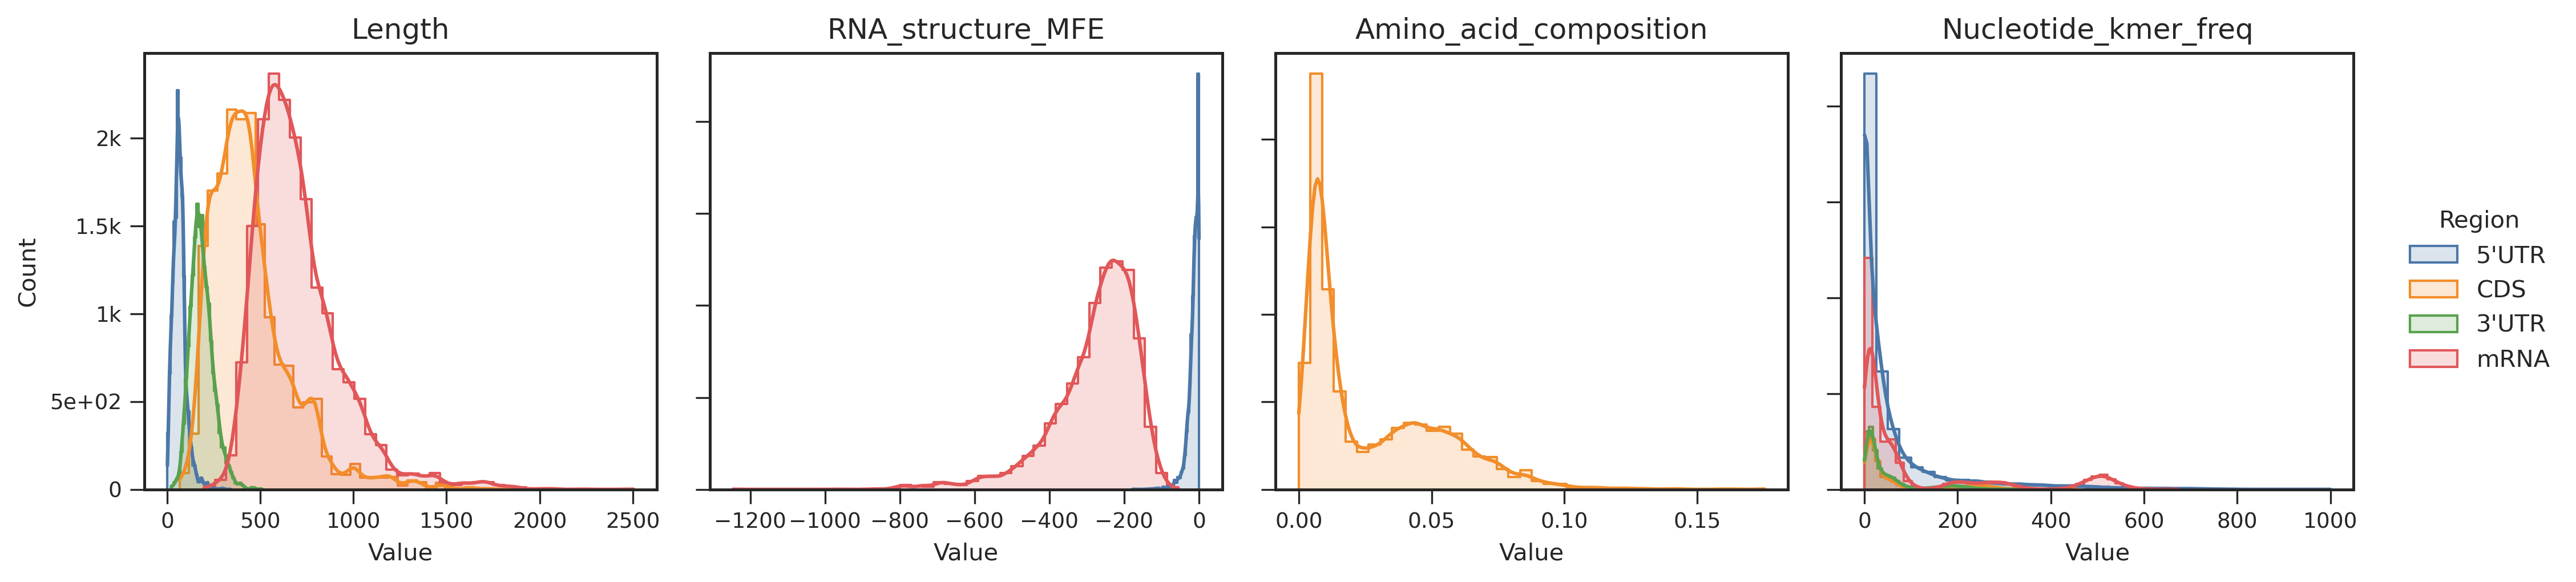

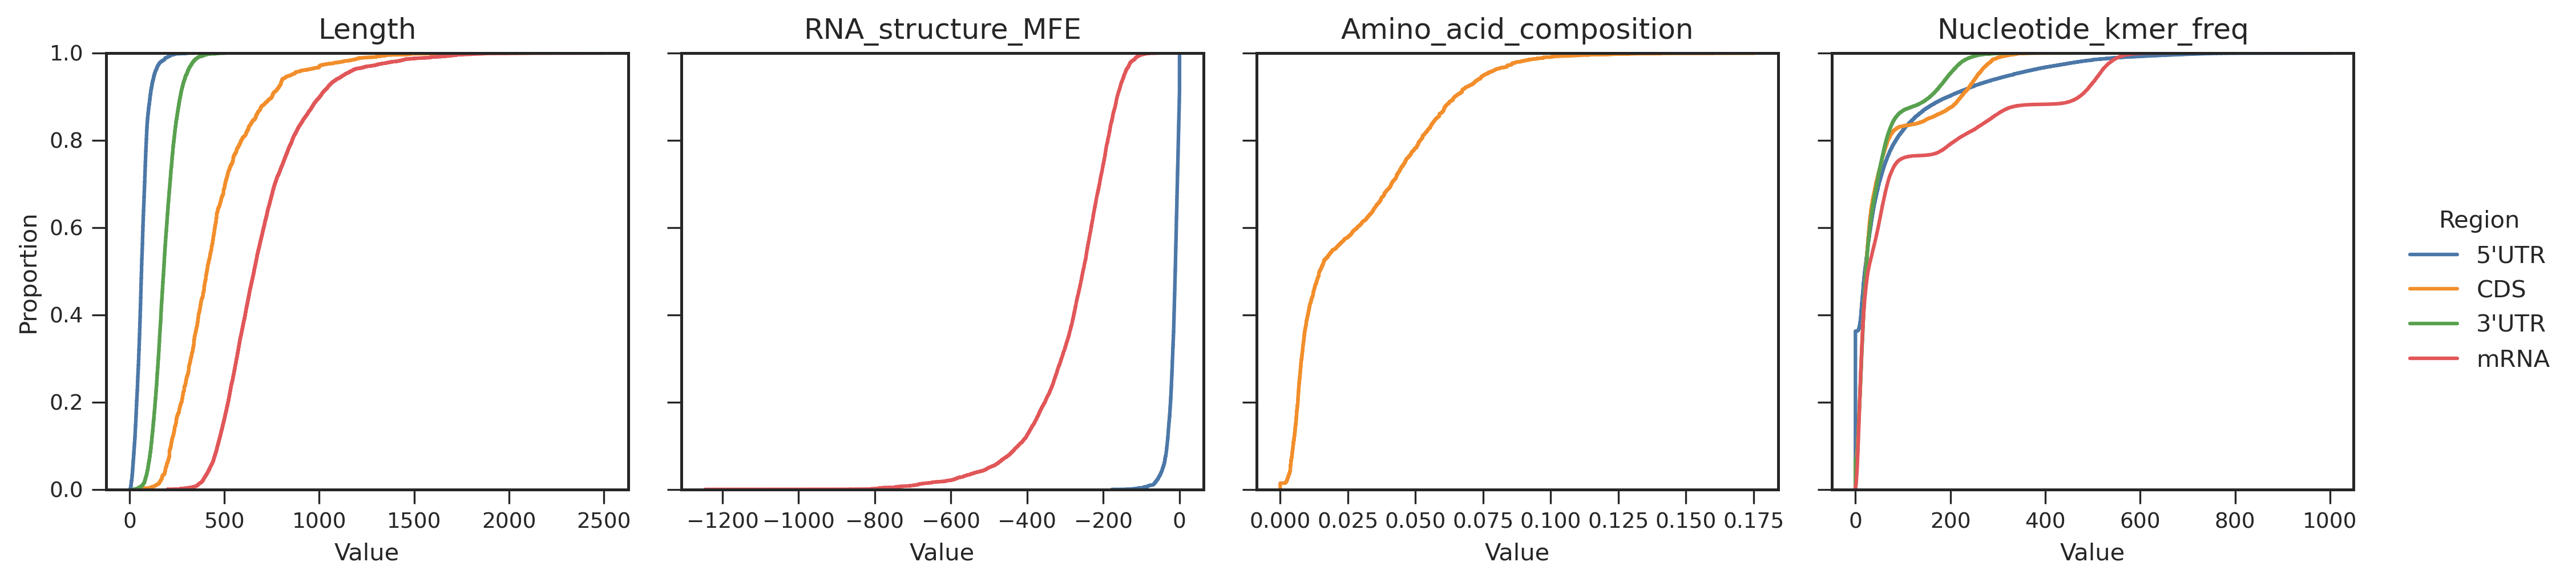

In [13]:
# ============================================
# Candidate feature distributions
# ============================================

feature_type_order = [
    "Length",
    "RNA_structure_MFE",
    "Amino_acid_composition",
    "Nucleotide_kmer_freq",
]

region_order = ["5'UTR", "CDS", "3'UTR", "mRNA"]

region_colors = {
    "5'UTR": "#4C78A8",
    "CDS": "#F28E2B",
    "3'UTR": "#59A14F",
    "mRNA": "#E15759",
}

plot_df = candidate_long_df.copy()
plot_df["Feature_type"] = pd.Categorical(plot_df["Feature_type"], categories=feature_type_order, ordered=True)
plot_df["Region"] = pd.Categorical(plot_df["Region"], categories=region_order, ordered=True)


# --------------------------------------------
# Histogram + KDE
# --------------------------------------------

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), dpi=_PLOT_CFG["dpi"])

for ax, feature_type in zip(axes, feature_type_order):

    temp = plot_df[plot_df["Feature_type"] == feature_type]

    for region in region_order:

        values = temp.loc[temp["Region"] == region, "Value"].dropna()

        if len(values) == 0:
            continue

        sns.histplot(
            values,
            bins=40,
            stat="count",
            element="step",
            fill=True,
            alpha=0.20,
            kde=True,
            color=region_colors[region],
            label=region,
            ax=ax,
        )

    ax.set_title(feature_type)

    format_axis(
        ax,
        xlabel="Value",
        ylabel="Count" if ax is axes[0] else "",
        compact_ticks=("y",),
    )

    if ax is not axes[0]:
        ax.tick_params(labelleft=False)

handles, labels = axes[-1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Region",
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.00, 0.5),
)

for ax in axes:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

plt.tight_layout()
plt.show()


# --------------------------------------------
# ECDF
# --------------------------------------------

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), dpi=_PLOT_CFG["dpi"])

for ax, feature_type in zip(axes, feature_type_order):

    temp = plot_df[plot_df["Feature_type"] == feature_type]

    for region in region_order:

        values = temp.loc[temp["Region"] == region, "Value"].dropna()

        if len(values) == 0:
            continue

        sns.ecdfplot(
            x=values,
            color=region_colors[region],
            linewidth=1.5,
            label=region,
            ax=ax,
        )

    ax.set_title(feature_type)

    format_axis(
        ax,
        xlabel="Value",
        ylabel="Proportion" if ax is axes[0] else "",
    )

    if ax is not axes[0]:
        ax.tick_params(labelleft=False)

handles, labels = axes[-1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Region",
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.00, 0.5),
)

for ax in axes:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

plt.tight_layout()
plt.show()

In [15]:
# ============================================
# Candidate feature summary by species
# ============================================

summary_rows = []

for species in sorted(candidate_master_df["Species"].unique()):

    species_df = (
        candidate_master_df[
            candidate_master_df["Species"] == species
        ]
        .reset_index(drop=True)
    )

    for feature in candidate_features:

        meta = feature_metadata_df.loc[
            feature_metadata_df["Feature"] == feature
        ].iloc[0]

        values = species_df[feature]

        q25 = values.quantile(0.25)
        q75 = values.quantile(0.75)

        summary_rows.append({

            "Species": species,
            "Feature": feature,
            "Region": meta["Region"],
            "Feature_type": meta["Feature_type"],

            "n": values.notna().sum(),
            "missing_n": values.isna().sum(),
            "missing_pct": values.isna().mean() * 100,

            "zero_n": (values == 0).sum(),
            "zero_pct": (values == 0).mean() * 100,

            "mean": values.mean(),
            "std": values.std(),

            "median": values.median(),
            "q25": q25,
            "q75": q75,
            "IQR": q75 - q25,

            "min": values.min(),
            "max": values.max(),

            "skew": stats.skew(
                values,
                nan_policy="omit",
            ),

            "kurtosis": stats.kurtosis(
                values,
                nan_policy="omit",
            ),

            "variance": values.var(),

            "cv": (
                values.std() / values.mean()
                if values.mean() != 0
                else np.nan
            ),
        })

candidate_species_summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values(
        ["Species", "Region", "Feature_type", "Feature"]
    )
    .reset_index(drop=True)
)

print("Candidate feature summary by species")
print("------------------------------------")
print(candidate_species_summary_df.shape)

display(candidate_species_summary_df.head(20))

print("\nHighest skew")
display(
    candidate_species_summary_df
    .sort_values("skew", key=np.abs, ascending=False)
    .head(10)
)

print("\nHighest kurtosis")
display(
    candidate_species_summary_df
    .sort_values("kurtosis", key=np.abs, ascending=False)
    .head(10)
)

print("\nHighest zero percentage")
display(
    candidate_species_summary_df
    .sort_values("zero_pct", ascending=False)
    .head(10)
)

print("\nHighest coefficient of variation")
display(
    candidate_species_summary_df
    .sort_values("cv", ascending=False)
    .head(10)
)

Candidate feature summary by species
------------------------------------
(183, 21)


,Species,Feature,Region,Feature_type,n,missing_n,missing_pct,zero_n,zero_pct,mean,...,median,q25,q75,IQR,min,max,skew,kurtosis,variance,cv
0,AT,3'UTR.Length,3'UTR,Length,7126,0,0.0,0,0.000000,166.093040,...,162.000000,133.000000,196.000000,63.000000,22.00000,414.000000,0.620357,1.219593,2488.377167,0.300336
1,AT,3'UTR.ACA-freq,3'UTR,Nucleotide_kmer_freq,7126,0,0.0,1486,20.853214,11.284752,...,9.708738,4.830918,16.393443,11.562525,0.00000,68.965517,1.298475,2.488143,98.647880,0.880140
2,AT,3'UTR.AG-freq,3'UTR,Nucleotide_kmer_freq,7126,0,0.0,40,0.561325,43.455944,...,42.372881,31.421845,54.263566,22.841721,0.00000,148.148148,0.533762,1.058897,327.341091,0.416343
3,AT,3'UTR.AUC-freq,3'UTR,Nucleotide_kmer_freq,7126,0,0.0,417,5.851810,18.525699,...,17.094017,10.309278,25.196871,14.887593,0.00000,105.263158,0.841680,1.544945,128.749862,0.612490
4,AT,3'UTR.G-freq,3'UTR,Nucleotide_kmer_freq,7126,0,0.0,0,0.000000,172.249670,...,172.774869,150.326797,193.798450,43.471652,21.73913,363.636364,-0.021329,1.015588,1169.416764,0.198530
5,AT,3'UTR.GAU-freq,3'UTR,Nucleotide_kmer_freq,7126,0,0.0,448,6.286837,19.107572,...,18.072289,10.989011,25.613748,14.624737,0.00000,128.205128,1.073421,3.768234,137.992326,0.614783
6,AT,3'UTR.GUA-freq,3'UTR,Nucleotide_kmer_freq,7126,0,0.0,982,13.780522,14.127441,...,12.738854,6.666667,20.134228,13.467562,0.00000,57.971014,0.740365,0.561022,103.199136,0.719076
7,AT,3'UTR.UAG-freq,3'UTR,Nucleotide_kmer_freq,7126,0,0.0,1655,23.224811,9.115598,...,7.812500,4.255319,13.605442,9.350123,0.00000,59.701493,0.905447,1.340316,57.475163,0.831677
8,AT,3'UTR.UC-freq,3'UTR,Nucleotide_kmer_freq,7126,0,0.0,1,0.014033,71.026575,...,69.230769,55.214724,85.470085,30.255362,0.00000,204.081633,0.544044,1.183576,563.839285,0.334316
9,AT,5'UTR.Length,5'UTR,Length,7126,0,0.0,0,0.000000,58.505754,...,56.000000,36.000000,75.000000,39.000000,1.00000,301.000000,1.531708,5.144842,1116.368458,0.571091



Highest skew


,Species,Feature,Region,Feature_type,n,missing_n,missing_pct,zero_n,zero_pct,mean,...,median,q25,q75,IQR,min,max,skew,kurtosis,variance,cv
147,OS,5'UTR.UAU-freq,5'UTR,Nucleotide_kmer_freq,5552,0,0.0,4681,84.311960,2.504039,...,0.0,0.0,0.000000,0.000000,0.0,93.023256,4.897579,34.031086,56.605838,3.004619
76,NB,5'UTR.CCC-freq,5'UTR,Nucleotide_kmer_freq,5381,0,0.0,3694,68.648950,9.204376,...,0.0,0.0,13.333333,13.333333,0.0,250.000000,4.425113,29.319253,417.034144,2.218664
25,AT,5'UTR.UAU-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,4859,68.186921,7.676439,...,0.0,0.0,12.987013,12.987013,0.0,200.000000,4.267204,34.854188,229.995845,1.975605
31,AT,5'UTR.UGG-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,5708,80.101038,4.340798,...,0.0,0.0,0.000000,0.000000,0.0,166.666667,4.257893,28.504023,125.870158,2.584591
132,OS,5'UTR.ACA-freq,5'UTR,Nucleotide_kmer_freq,5552,0,0.0,2818,50.756484,14.642185,...,0.0,0.0,20.000000,20.000000,0.0,269.230769,3.548465,22.903271,585.323090,1.652312
30,AT,5'UTR.UGC-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,5082,71.316306,6.051929,...,0.0,0.0,10.680965,10.680965,0.0,133.333333,3.443196,19.527211,152.422847,2.040005
153,OS,5'UTR.UGG-freq,5'UTR,Nucleotide_kmer_freq,5552,0,0.0,4205,75.738473,4.281709,...,0.0,0.0,0.000000,0.000000,0.0,100.000000,3.343287,15.488477,91.482640,2.233841
92,NB,5'UTR.UGG-freq,5'UTR,Nucleotide_kmer_freq,5381,0,0.0,4349,80.821409,3.853585,...,0.0,0.0,0.000000,0.000000,0.0,125.000000,3.244647,13.914384,91.364762,2.480415
12,AT,5'UTR.AGG-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,4514,63.345495,9.556560,...,0.0,0.0,14.925373,14.925373,0.0,214.285714,3.234545,16.559598,307.298290,1.834334
15,AT,5'UTR.CCC-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,5598,78.557395,4.715160,...,0.0,0.0,0.000000,0.000000,0.0,108.108108,3.199417,13.382437,123.064543,2.352719



Highest kurtosis


,Species,Feature,Region,Feature_type,n,missing_n,missing_pct,zero_n,zero_pct,mean,...,median,q25,q75,IQR,min,max,skew,kurtosis,variance,cv
25,AT,5'UTR.UAU-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,4859,68.186921,7.676439,...,0.0,0.0,12.987013,12.987013,0.0,200.000000,4.267204,34.854188,229.995845,1.975605
147,OS,5'UTR.UAU-freq,5'UTR,Nucleotide_kmer_freq,5552,0,0.0,4681,84.311960,2.504039,...,0.0,0.0,0.000000,0.000000,0.0,93.023256,4.897579,34.031086,56.605838,3.004619
76,NB,5'UTR.CCC-freq,5'UTR,Nucleotide_kmer_freq,5381,0,0.0,3694,68.648950,9.204376,...,0.0,0.0,13.333333,13.333333,0.0,250.000000,4.425113,29.319253,417.034144,2.218664
31,AT,5'UTR.UGG-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,5708,80.101038,4.340798,...,0.0,0.0,0.000000,0.000000,0.0,166.666667,4.257893,28.504023,125.870158,2.584591
132,OS,5'UTR.ACA-freq,5'UTR,Nucleotide_kmer_freq,5552,0,0.0,2818,50.756484,14.642185,...,0.0,0.0,20.000000,20.000000,0.0,269.230769,3.548465,22.903271,585.323090,1.652312
30,AT,5'UTR.UGC-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,5082,71.316306,6.051929,...,0.0,0.0,10.680965,10.680965,0.0,133.333333,3.443196,19.527211,152.422847,2.040005
73,NB,5'UTR.AGG-freq,5'UTR,Nucleotide_kmer_freq,5381,0,0.0,3065,56.959673,11.265492,...,0.0,0.0,18.181818,18.181818,0.0,250.000000,3.049617,18.126434,330.442264,1.613606
12,AT,5'UTR.AGG-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,4514,63.345495,9.556560,...,0.0,0.0,14.925373,14.925373,0.0,214.285714,3.234545,16.559598,307.298290,1.834334
153,OS,5'UTR.UGG-freq,5'UTR,Nucleotide_kmer_freq,5552,0,0.0,4205,75.738473,4.281709,...,0.0,0.0,0.000000,0.000000,0.0,100.000000,3.343287,15.488477,91.482640,2.233841
133,OS,5'UTR.ACU-freq,5'UTR,Nucleotide_kmer_freq,5552,0,0.0,3148,56.700288,8.854476,...,0.0,0.0,14.492754,14.492754,0.0,130.434783,2.906196,14.392104,197.647165,1.587751



Highest zero percentage


,Species,Feature,Region,Feature_type,n,missing_n,missing_pct,zero_n,zero_pct,mean,...,median,q25,q75,IQR,min,max,skew,kurtosis,variance,cv
147,OS,5'UTR.UAU-freq,5'UTR,Nucleotide_kmer_freq,5552,0,0.0,4681,84.311960,2.504039,...,0.0,0.0,0.000000,0.000000,0.0,93.023256,4.897579,34.031086,56.605838,3.004619
92,NB,5'UTR.UGG-freq,5'UTR,Nucleotide_kmer_freq,5381,0,0.0,4349,80.821409,3.853585,...,0.0,0.0,0.000000,0.000000,0.0,125.000000,3.244647,13.914384,91.364762,2.480415
31,AT,5'UTR.UGG-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,5708,80.101038,4.340798,...,0.0,0.0,0.000000,0.000000,0.0,166.666667,4.257893,28.504023,125.870158,2.584591
15,AT,5'UTR.CCC-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,5598,78.557395,4.715160,...,0.0,0.0,0.000000,0.000000,0.0,108.108108,3.199417,13.382437,123.064543,2.352719
153,OS,5'UTR.UGG-freq,5'UTR,Nucleotide_kmer_freq,5552,0,0.0,4205,75.738473,4.281709,...,0.0,0.0,0.000000,0.000000,0.0,100.000000,3.343287,15.488477,91.482640,2.233841
77,NB,5'UTR.CCG-freq,5'UTR,Nucleotide_kmer_freq,5381,0,0.0,3847,71.492288,6.600226,...,0.0,0.0,11.363636,11.363636,0.0,111.111111,2.660171,9.048071,170.440176,1.978004
30,AT,5'UTR.UGC-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,5082,71.316306,6.051929,...,0.0,0.0,10.680965,10.680965,0.0,133.333333,3.443196,19.527211,152.422847,2.040005
76,NB,5'UTR.CCC-freq,5'UTR,Nucleotide_kmer_freq,5381,0,0.0,3694,68.648950,9.204376,...,0.0,0.0,13.333333,13.333333,0.0,250.000000,4.425113,29.319253,417.034144,2.218664
25,AT,5'UTR.UAU-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,4859,68.186921,7.676439,...,0.0,0.0,12.987013,12.987013,0.0,200.000000,4.267204,34.854188,229.995845,1.975605
16,AT,5'UTR.CCG-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,4768,66.909907,7.747402,...,0.0,0.0,13.157895,13.157895,0.0,142.857143,2.474153,8.496293,194.735318,1.801218



Highest coefficient of variation


,Species,Feature,Region,Feature_type,n,missing_n,missing_pct,zero_n,zero_pct,mean,...,median,q25,q75,IQR,min,max,skew,kurtosis,variance,cv
147,OS,5'UTR.UAU-freq,5'UTR,Nucleotide_kmer_freq,5552,0,0.0,4681,84.311960,2.504039,...,0.0,0.0,0.000000,0.000000,0.0,93.023256,4.897579,34.031086,56.605838,3.004619
31,AT,5'UTR.UGG-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,5708,80.101038,4.340798,...,0.0,0.0,0.000000,0.000000,0.0,166.666667,4.257893,28.504023,125.870158,2.584591
92,NB,5'UTR.UGG-freq,5'UTR,Nucleotide_kmer_freq,5381,0,0.0,4349,80.821409,3.853585,...,0.0,0.0,0.000000,0.000000,0.0,125.000000,3.244647,13.914384,91.364762,2.480415
15,AT,5'UTR.CCC-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,5598,78.557395,4.715160,...,0.0,0.0,0.000000,0.000000,0.0,108.108108,3.199417,13.382437,123.064543,2.352719
153,OS,5'UTR.UGG-freq,5'UTR,Nucleotide_kmer_freq,5552,0,0.0,4205,75.738473,4.281709,...,0.0,0.0,0.000000,0.000000,0.0,100.000000,3.343287,15.488477,91.482640,2.233841
76,NB,5'UTR.CCC-freq,5'UTR,Nucleotide_kmer_freq,5381,0,0.0,3694,68.648950,9.204376,...,0.0,0.0,13.333333,13.333333,0.0,250.000000,4.425113,29.319253,417.034144,2.218664
30,AT,5'UTR.UGC-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,5082,71.316306,6.051929,...,0.0,0.0,10.680965,10.680965,0.0,133.333333,3.443196,19.527211,152.422847,2.040005
77,NB,5'UTR.CCG-freq,5'UTR,Nucleotide_kmer_freq,5381,0,0.0,3847,71.492288,6.600226,...,0.0,0.0,11.363636,11.363636,0.0,111.111111,2.660171,9.048071,170.440176,1.978004
25,AT,5'UTR.UAU-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,4859,68.186921,7.676439,...,0.0,0.0,12.987013,12.987013,0.0,200.000000,4.267204,34.854188,229.995845,1.975605
12,AT,5'UTR.AGG-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,4514,63.345495,9.556560,...,0.0,0.0,14.925373,14.925373,0.0,214.285714,3.234545,16.559598,307.298290,1.834334


In [16]:
# ============================================
# Candidate-feature correlation matrices
# ============================================

correlation_dict = {}

for species_key in SPECIES:

    species = SPECIES_INFO[species_key]["label"]

    feature_df = (
        candidate_master_df
        .loc[
            candidate_master_df["Species"] == species,
            candidate_features,
        ]
        .copy()
    )

    corr = feature_df.corr(
        method="spearman",
    )

    correlation_dict[species_key] = corr

    print(f"{species_key}")
    print(corr.shape)
    display(corr.iloc[:5, :5])
    print()

AT21
(61, 61)


,3'UTR.ACA-freq,3'UTR.AG-freq,3'UTR.AUC-freq,3'UTR.G-freq,3'UTR.GAU-freq
3'UTR.ACA-freq,1.000000,0.123291,0.003866,-0.210627,-0.119391
3'UTR.AG-freq,0.123291,1.000000,-0.089267,0.343586,0.046116
3'UTR.AUC-freq,0.003866,-0.089267,1.000000,-0.249175,0.073869
3'UTR.G-freq,-0.210627,0.343586,-0.249175,1.000000,0.252996
3'UTR.GAU-freq,-0.119391,0.046116,0.073869,0.252996,1.000000



NB21
(61, 61)


,3'UTR.ACA-freq,3'UTR.AG-freq,3'UTR.AUC-freq,3'UTR.G-freq,3'UTR.GAU-freq
3'UTR.ACA-freq,1.000000,0.074243,0.147105,-0.142624,-0.112511
3'UTR.AG-freq,0.074243,1.000000,-0.039742,0.424184,-0.001160
3'UTR.AUC-freq,0.147105,-0.039742,1.000000,-0.160695,0.058427
3'UTR.G-freq,-0.142624,0.424184,-0.160695,1.000000,0.186992
3'UTR.GAU-freq,-0.112511,-0.001160,0.058427,0.186992,1.000000



OS21
(61, 61)


,3'UTR.ACA-freq,3'UTR.AG-freq,3'UTR.AUC-freq,3'UTR.G-freq,3'UTR.GAU-freq
3'UTR.ACA-freq,1.000000,0.025452,0.015587,-0.272732,-0.088722
3'UTR.AG-freq,0.025452,1.000000,-0.171084,0.295827,-0.003433
3'UTR.AUC-freq,0.015587,-0.171084,1.000000,-0.280111,0.124518
3'UTR.G-freq,-0.272732,0.295827,-0.280111,1.000000,0.215621
3'UTR.GAU-freq,-0.088722,-0.003433,0.124518,0.215621,1.000000


In [17]:
# ============================================
# Hierarchical clustering of candidate features
# ============================================

from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

cluster_dict = {}
ordered_feature_dict = {}

for species_key in SPECIES:

    corr = correlation_dict[species_key]

    # correlation distance
    dist = 1 - np.abs(corr)

    np.fill_diagonal(dist.values, 0)

    linkage = hierarchy.linkage(
        squareform(dist),
        method="average",
    )

    leaves = hierarchy.leaves_list(linkage)

    ordered_features = corr.index[leaves].tolist()

    cluster_dict[species_key] = linkage
    ordered_feature_dict[species_key] = ordered_features

    print(species_key)
    print(f"Clusters built for {len(ordered_features)} features.")
    print("First 10 ordered features:")
    print(ordered_features[:10])
    print()

AT21
Clusters built for 61 features.
First 10 ordered features:
['mRNA.GCG-freq', "3'UTR.Length", "3'UTR.GUA-freq", 'mRNA.GUA-freq', "3'UTR.AG-freq", "3'UTR.UAG-freq", 'mRNA.UAG-freq', "3'UTR.GAU-freq", "3'UTR.AUC-freq", 'mRNA.AUC-freq']

NB21
Clusters built for 61 features.
First 10 ordered features:
["3'UTR.ACA-freq", "3'UTR.GAU-freq", "5'UTR.UGG-freq", "5'UTR.Length", "5'UTR.MFE", "5'UTR.UG-freq", "5'UTR.UGC-freq", "5'UTR.CC-freq", "5'UTR.CCC-freq", "5'UTR.CCG-freq"]

OS21
Clusters built for 61 features.
First 10 ordered features:
["3'UTR.GUA-freq", 'mRNA.GUA-freq', "5'UTR.Length", "5'UTR.MFE", "5'UTR.UGG-freq", "5'UTR.UG-freq", "5'UTR.UGC-freq", "5'UTR.ACU-freq", "5'UTR.CUU-freq", "5'UTR.AGG-freq"]



In [19]:
# ============================================
# Inspect candidate-feature hierarchical clusters
# ============================================

from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import silhouette_score

cluster_eval_rows = []
cluster_rows = []

for species_key in SPECIES:

    species = SPECIES_INFO[species_key]["label"]
    corr = correlation_dict[species_key].loc[candidate_features, candidate_features].copy()
    linkage = cluster_dict[species_key]

    # ----------------------------------------
    # Correlation distance used for clustering
    # ----------------------------------------

    distance = 1 - np.abs(corr)
    np.fill_diagonal(distance.values, 0)

    # ----------------------------------------
    # Evaluate cluster number
    # ----------------------------------------

    species_eval = []

    for k in range(2, 11):

        labels = fcluster(linkage, t=k, criterion="maxclust")

        score = silhouette_score(
            distance.values,
            labels,
            metric="precomputed",
        )

        species_eval.append({
            "Species": species,
            "Species_key": species_key,
            "k": k,
            "Silhouette": score,
        })

    species_eval_df = pd.DataFrame(species_eval)
    cluster_eval_rows.append(species_eval_df)

    best_k = int(
        species_eval_df.loc[
            species_eval_df["Silhouette"].idxmax(),
            "k",
        ]
    )

    # ----------------------------------------
    # Final cluster assignment for inspection
    # ----------------------------------------

    labels = fcluster(linkage, t=best_k, criterion="maxclust")

    species_cluster_df = pd.DataFrame({
        "Species": species,
        "Species_key": species_key,
        "Feature": corr.index,
        "Cluster": labels,
    })

    species_cluster_df = species_cluster_df.merge(
        feature_metadata_df,
        on="Feature",
        how="left",
        validate="one_to_one",
    )

    cluster_rows.append(species_cluster_df)


# ============================================
# Combine results
# ============================================

cluster_evaluation_df = pd.concat(cluster_eval_rows, ignore_index=True)
candidate_cluster_df = pd.concat(cluster_rows, ignore_index=True)


# --------------------------------------------
# 1. Silhouette evaluation
# --------------------------------------------

print("Silhouette evaluation")
print("---------------------")

display(
    cluster_evaluation_df.pivot(
        index="k",
        columns="Species",
        values="Silhouette",
    )
)


# --------------------------------------------
# 2. Best cluster number
# --------------------------------------------

best_cluster_df = (
    cluster_evaluation_df
    .loc[
        cluster_evaluation_df.groupby("Species")["Silhouette"].idxmax(),
        ["Species", "k", "Silhouette"],
    ]
    .sort_values("Species")
    .reset_index(drop=True)
)

print("\nBest cluster number")
display(best_cluster_df)


# --------------------------------------------
# 3. Cluster sizes
# --------------------------------------------

cluster_size_df = (
    candidate_cluster_df
    .groupby(["Species", "Cluster"], as_index=False)
    .agg(n_features=("Feature", "size"))
)

print("\nCluster sizes")
display(cluster_size_df)


# --------------------------------------------
# 4. Region composition
# --------------------------------------------

cluster_region_df = pd.crosstab(
    [candidate_cluster_df["Species"], candidate_cluster_df["Cluster"]],
    candidate_cluster_df["Region"],
)

print("\nCluster × Region")
display(cluster_region_df)


# --------------------------------------------
# 5. Feature-type composition
# --------------------------------------------

cluster_type_df = pd.crosstab(
    [candidate_cluster_df["Species"], candidate_cluster_df["Cluster"]],
    candidate_cluster_df["Feature_type"],
)

print("\nCluster × Feature type")
display(cluster_type_df)


# --------------------------------------------
# 6. Full annotated cluster membership
# --------------------------------------------

candidate_cluster_df = (
    candidate_cluster_df
    .sort_values(["Species", "Cluster", "Region", "Feature_type", "Feature"])
    .reset_index(drop=True)
)

print("\nCluster membership")
display(candidate_cluster_df)

Silhouette evaluation
---------------------


Species,AT,NB,OS
k,,,
2,0.104787,0.067680,0.121439
3,0.094272,0.092939,0.108308
4,0.076178,0.102961,0.113257
5,0.089054,0.103625,0.123564
6,0.092854,0.131321,0.111979
7,0.103010,0.129092,0.130119
8,0.091168,0.125478,0.175151
9,0.083361,0.115979,0.172824
10,0.074747,0.131633,0.185707



Best cluster number


,Species,k,Silhouette
0,AT,2,0.104787
1,NB,10,0.131633
2,OS,10,0.185707



Cluster sizes


...

Region           3'UTR  5'UTR  CDS  mRNA
Species Cluster                         
AT      1            8      0    9    18
        2            1     24    0     1
NB      1            1      0    0     0
        2            1      0    0     0
        3            0     23    0     0
        4            0      1    0     0
        5            0      0    0     1
        6            2      0    0     1
        7            1      0    0     1
        8            4      0    2     3
        9            0      0    4     9
        10           0      0    3     4
OS      1            1      0    0     1
        2            0      5    0     0
        3            0     19    0     0
        4            3      0    0     0
        5            2      0    1     1
        6            2      0    0     2
        7            0      0    0     1
        8            0      0    5    12
        9            1      0    2     2
        10           0      0    1     0


Cluster × Feature type


Feature_type     Amino_acid_composition  Length  Nucleotide_kmer_freq  \
Species Cluster                                                         
AT      1                             2       3                    29   
        2                             0       1                    24   
NB      1                             0       0                     1   
        2                             0       0                     1   
        3                             0       1                    21   
        4                             0       0                     1   
        5                             0       0                     1   
        6                             0       0                     3   
        7                             0       0                     2   
        8                             1       3                     4   
        9                             0       0                    13   
        10                            1       0                     6   
OS      1                             0       0                     2   
        2                             0       1                     3   
        3                             0       0                    19   
        4                             0       0                     3   
        5                             1       0                     3   
        6                             0       0                     4   
        7                             0       0                     1   
        8                             0       0                    17   
        9                             1       3                     0   
        10                            0       0                     1   

Feature_type     RNA_structure_MFE  
Species Cluster                     
AT      1                        1  
        2                        1  
NB      1                        0  
        2                        0  
        3                        1  
        4                        0  
        5                        0  
        6                        0  
        7                        0  
        8                        1  
        9                        0  
        10                       0  
OS      1                        0  
        2                        1  
        3                        0  
        4                        0  
        5                        0  
        6                        0  
        7                        0  
        8                        0  
        9                        1  
        10                       0


Cluster membership


,Species,Species_key,Feature,Cluster,Region,Feature_type
0,AT,AT21,3'UTR.Length,1,3'UTR,Length
1,AT,AT21,3'UTR.AG-freq,1,3'UTR,Nucleotide_kmer_freq
2,AT,AT21,3'UTR.AUC-freq,1,3'UTR,Nucleotide_kmer_freq
3,AT,AT21,3'UTR.G-freq,1,3'UTR,Nucleotide_kmer_freq
4,AT,AT21,3'UTR.GAU-freq,1,3'UTR,Nucleotide_kmer_freq
...,...,...,...,...,...,...
178,OS,OS21,CDS.aa_pct_X,9,CDS,Amino_acid_composition
179,OS,OS21,CDS.Length,9,CDS,Length
180,OS,OS21,mRNA.Length,9,mRNA,Length
181,OS,OS21,mRNA.MFE,9,mRNA,RNA_structure_MFE


Extended silhouette evaluation


Species,AT,NB,OS
k,,,
2,0.104787,0.067680,0.121439
3,0.094272,0.092939,0.108308
4,0.076178,0.102961,0.113257
5,0.089054,0.103625,0.123564
6,0.092854,0.131321,0.111979
7,0.103010,0.129092,0.130119
8,0.091168,0.125478,0.175151
9,0.083361,0.115979,0.172824
10,0.074747,0.131633,0.185707



Best k within 2–20


,Species,k,n_clusters,Silhouette
0,AT,20,20,0.164705
1,NB,20,20,0.253312
2,OS,16,16,0.253243


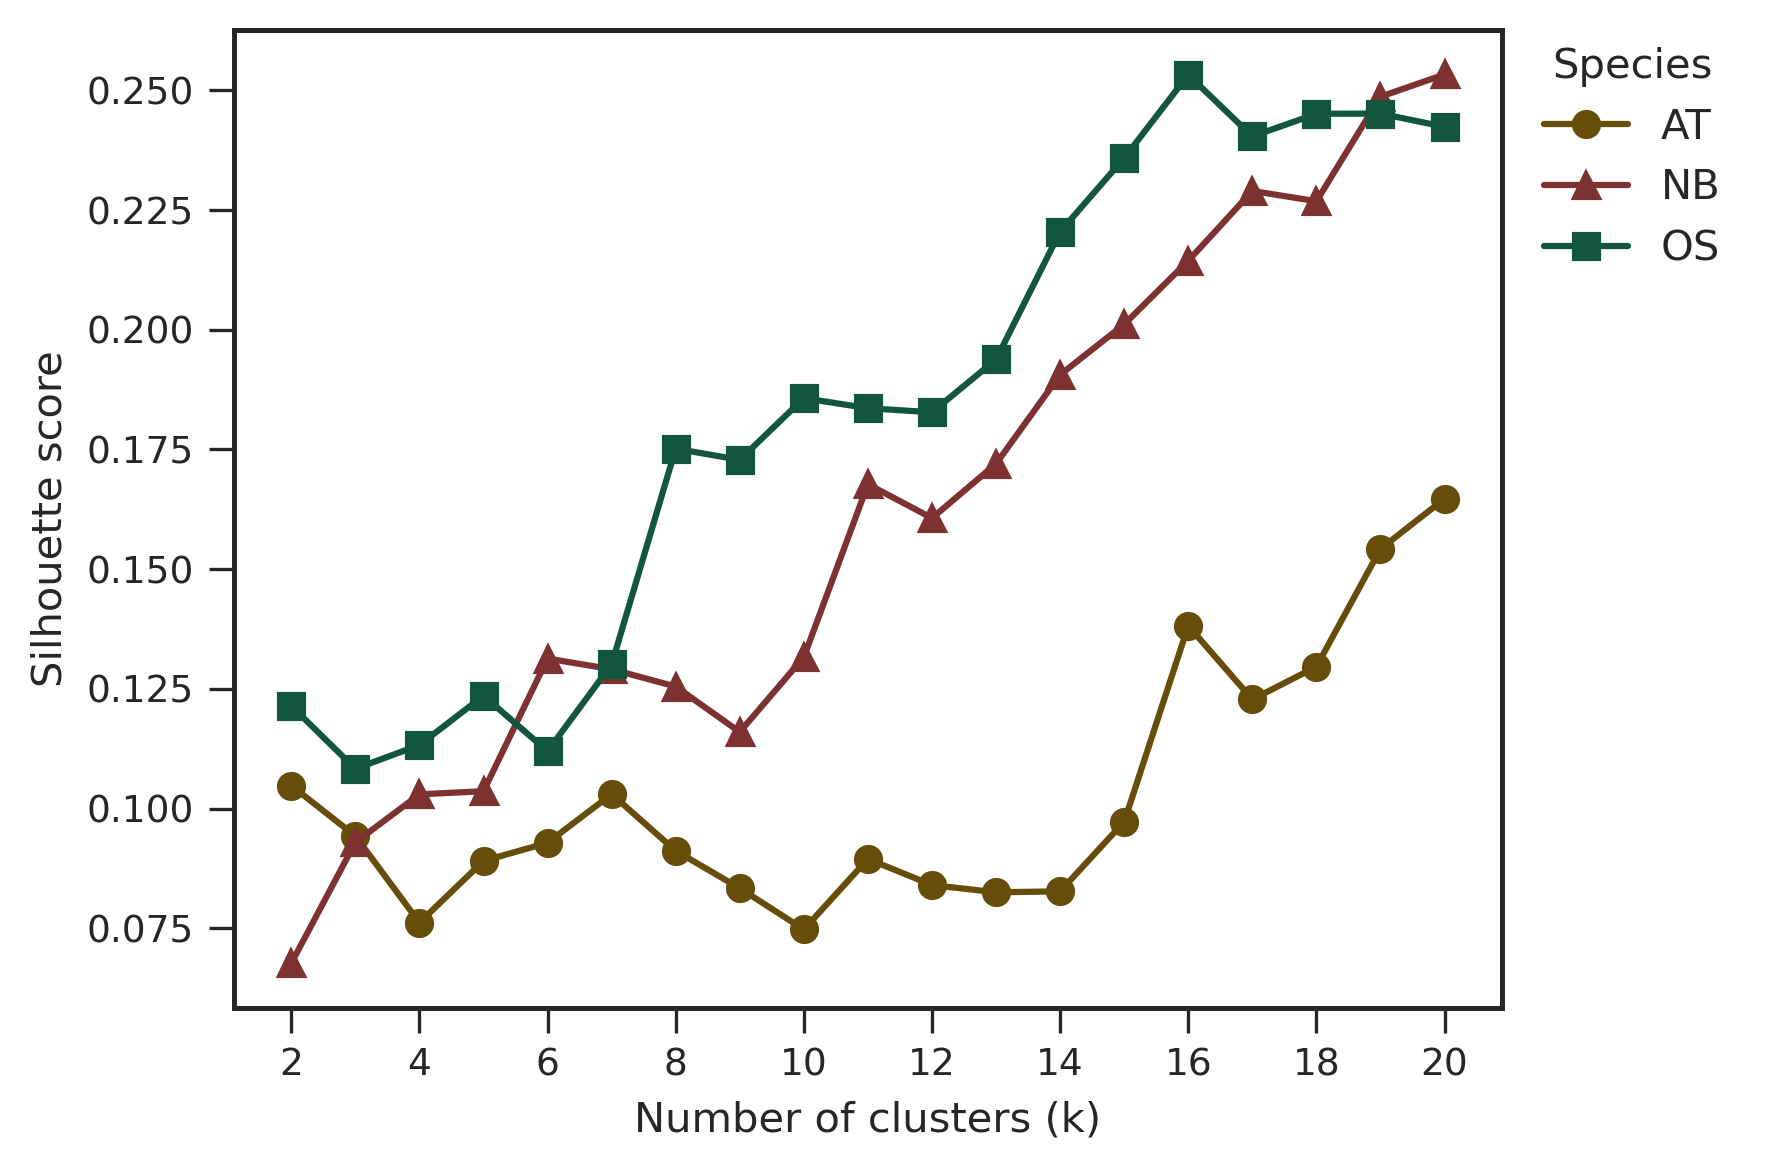

In [20]:
# ============================================
# Extended hierarchical cluster inspection
# ============================================

cluster_eval_rows = []

for species_key in SPECIES:

    species = SPECIES_INFO[species_key]["label"]
    corr = correlation_dict[species_key].loc[candidate_features, candidate_features].copy()
    linkage = cluster_dict[species_key]

    distance = 1 - np.abs(corr)
    np.fill_diagonal(distance.values, 0)

    for k in range(2, 21):

        labels = fcluster(linkage, t=k, criterion="maxclust")
        n_clusters = len(np.unique(labels))

        if n_clusters < 2 or n_clusters >= len(candidate_features):
            continue

        cluster_eval_rows.append({
            "Species": species,
            "k": k,
            "n_clusters": n_clusters,
            "Silhouette": silhouette_score(distance.values, labels, metric="precomputed"),
        })

cluster_evaluation_extended_df = pd.DataFrame(cluster_eval_rows)

print("Extended silhouette evaluation")
display(
    cluster_evaluation_extended_df.pivot(
        index="k",
        columns="Species",
        values="Silhouette",
    )
)

print("\nBest k within 2–20")
display(
    cluster_evaluation_extended_df.loc[
        cluster_evaluation_extended_df.groupby("Species")["Silhouette"].idxmax()
    ][["Species", "k", "n_clusters", "Silhouette"]]
    .sort_values("Species")
    .reset_index(drop=True)
)

# --------------------------------------------
# Silhouette curves
# --------------------------------------------

fig, ax = make_fig(w=6, h=4)

for species_key in SPECIES:
    species = SPECIES_INFO[species_key]["label"]
    temp = cluster_evaluation_extended_df[cluster_evaluation_extended_df["Species"] == species]

    ax.plot(
        temp["k"],
        temp["Silhouette"],
        marker=SPECIES_INFO[species_key]["marker"],
        color=SPECIES_INFO[species_key]["color"],
        label=species,
    )

format_axis(ax, xlabel="Number of clusters (k)", ylabel="Silhouette score")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
outside_legend(ax, title="Species")

plt.tight_layout()
plt.show()

In [21]:
# ============================================
# Prepare transformed candidate-feature data
# Exact feature space used by LightGBM
# ============================================

model_rows = []

for species_key in SPECIES:

    species = SPECIES_INFO[species_key]["label"]
    bundle = lgbm_data[species_key]

    x_model = pd.concat([bundle["x_train_model"], bundle["x_test_model"]], axis=0)[candidate_features].copy()
    metadata = pd.concat([bundle["train_metadata"], bundle["test_metadata"]], axis=0).copy()

    assert x_model.index.equals(metadata.index)
    assert list(x_model.columns) == candidate_features

    species_df = pd.concat([metadata, x_model], axis=1)
    species_df.insert(0, "Species", species)
    species_df.insert(1, "Species_key", species_key)

    model_rows.append(species_df)

candidate_model_master_df = pd.concat(model_rows, ignore_index=True)

# --------------------------------------------
# Integrity checks
# --------------------------------------------

assert len(candidate_model_master_df) == len(candidate_master_df)
assert candidate_model_master_df["Species"].value_counts().sort_index().equals(
    candidate_master_df["Species"].value_counts().sort_index()
)

print("Transformed candidate-feature dataset")
print("-------------------------------------")
print("Shape    :", candidate_model_master_df.shape)
print("Features :", len(candidate_features))

print("\nSpecies counts")
display(candidate_model_master_df["Species"].value_counts())

# --------------------------------------------
# Transformation sanity check by species
# --------------------------------------------

transform_check_rows = []

for species in ["AT", "NB", "OS"]:

    temp = candidate_model_master_df.loc[candidate_model_master_df["Species"] == species, candidate_features]

    transform_check_rows.append({
        "Species": species,
        "Mean_abs_feature_mean": temp.mean().abs().mean(),
        "Mean_feature_SD": temp.std().mean(),
        "Min_feature_SD": temp.std().min(),
        "Max_feature_SD": temp.std().max(),
        "Missing_values": int(temp.isna().sum().sum()),
    })

transform_check_df = pd.DataFrame(transform_check_rows)

print("\nTransformation sanity check")
display(transform_check_df)

Transformed candidate-feature dataset
-------------------------------------
Shape    : (18059, 70)
Features : 61

Species counts


Species
AT    7126
OS    5552
NB    5381
Name: count, dtype: int64


Transformation sanity check


,Species,Mean_abs_feature_mean,Mean_feature_SD,Min_feature_SD,Max_feature_SD,Missing_values
0,AT,0.004279,0.998224,0.987035,1.005031,0
1,NB,0.004563,0.999097,0.989444,1.011892,0
2,OS,0.003555,1.002359,0.993400,1.022370,0


In [22]:
# ============================================
# Candidate-feature correlation matrices
# (model-transformed feature space)
# ============================================

corr_matrices = {}
linkage_matrices = {}
feature_orders = {}

for species_key in SPECIES:

    species = SPECIES_INFO[species_key]["label"]

    X = (
        candidate_model_master_df
        .loc[
            candidate_model_master_df["Species"] == species,
            candidate_features,
        ]
        .copy()
    )

    # ----------------------------------------
    # Spearman correlation
    # ----------------------------------------

    corr = X.corr(method="spearman")

    # ----------------------------------------
    # Hierarchical clustering
    # ----------------------------------------

    distance = 1 - corr

    np.fill_diagonal(distance.values, 0)

    linkage = hierarchy.linkage(
        squareform(distance.values),
        method="average",
    )

    order = hierarchy.leaves_list(linkage)

    ordered_features = corr.index[order].tolist()

    corr_matrices[species_key] = corr
    linkage_matrices[species_key] = linkage
    feature_orders[species_key] = ordered_features

print("Correlation matrices")

for species_key in SPECIES:

    print(
        f"{species_key}:",
        corr_matrices[species_key].shape,
        "| ordered features:",
        len(feature_orders[species_key]),
    )

Correlation matrices
AT21: (61, 61) | ordered features: 61
NB21: (61, 61) | ordered features: 61
OS21: (61, 61) | ordered features: 61


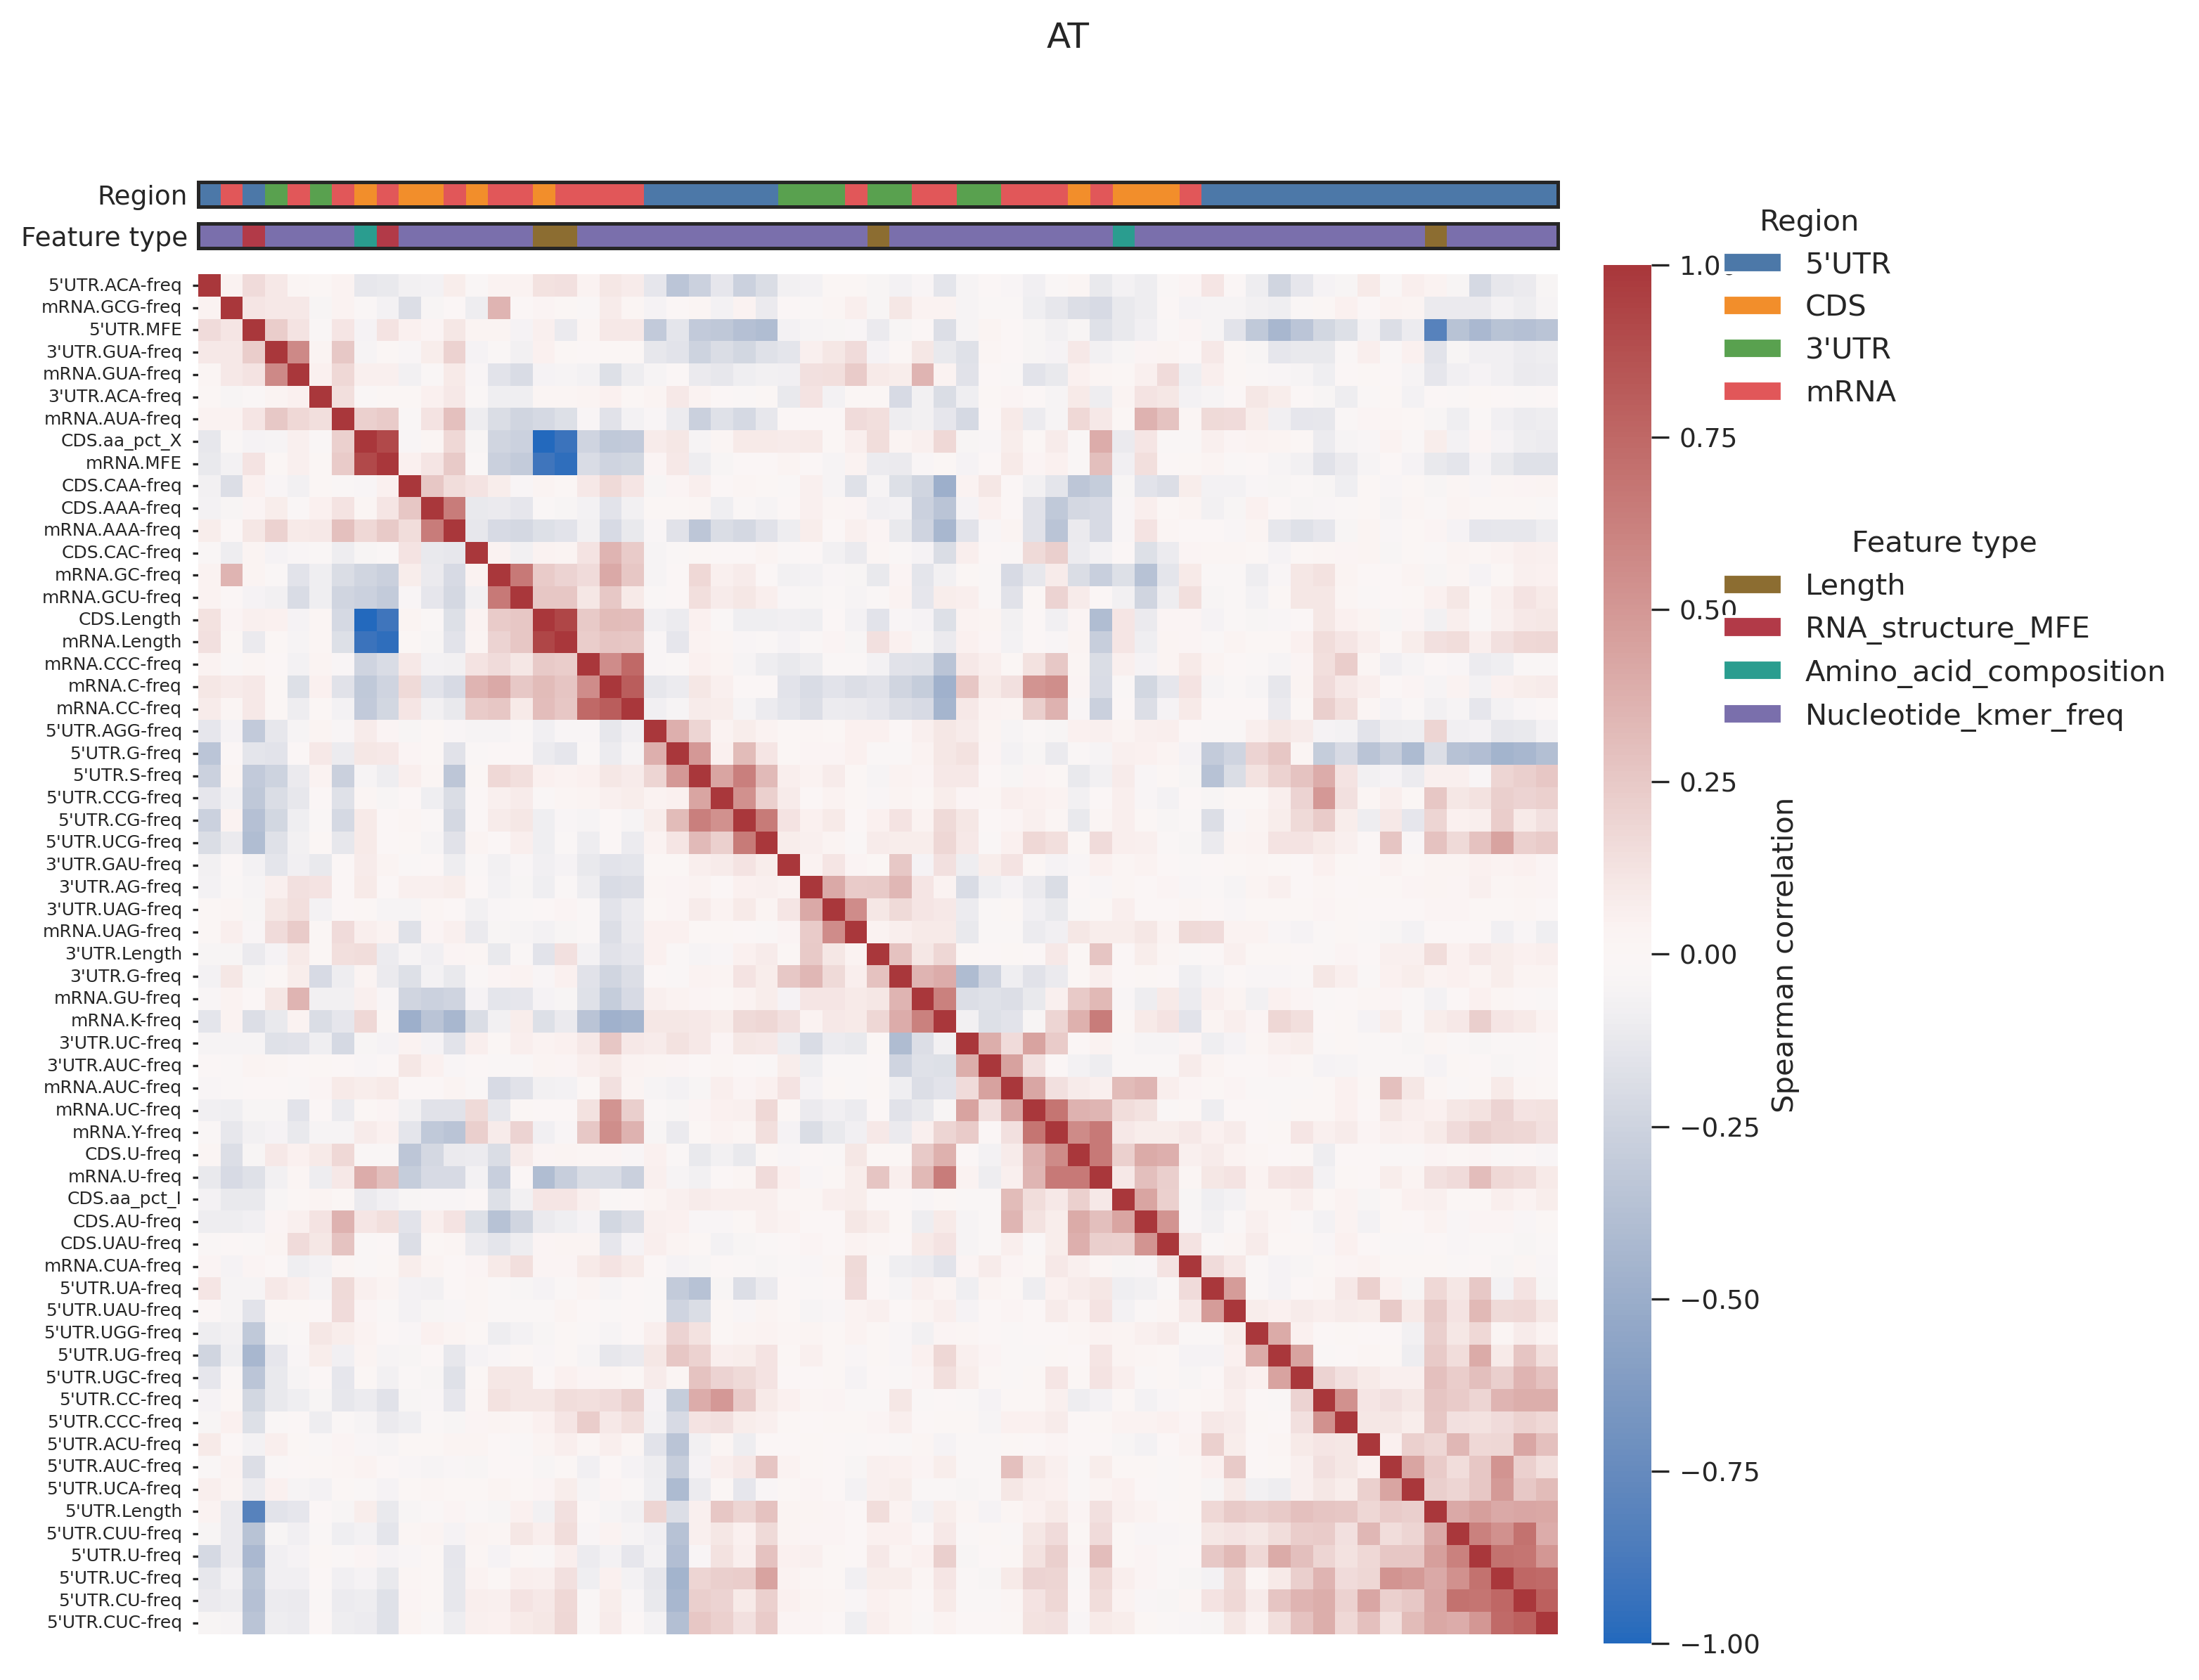

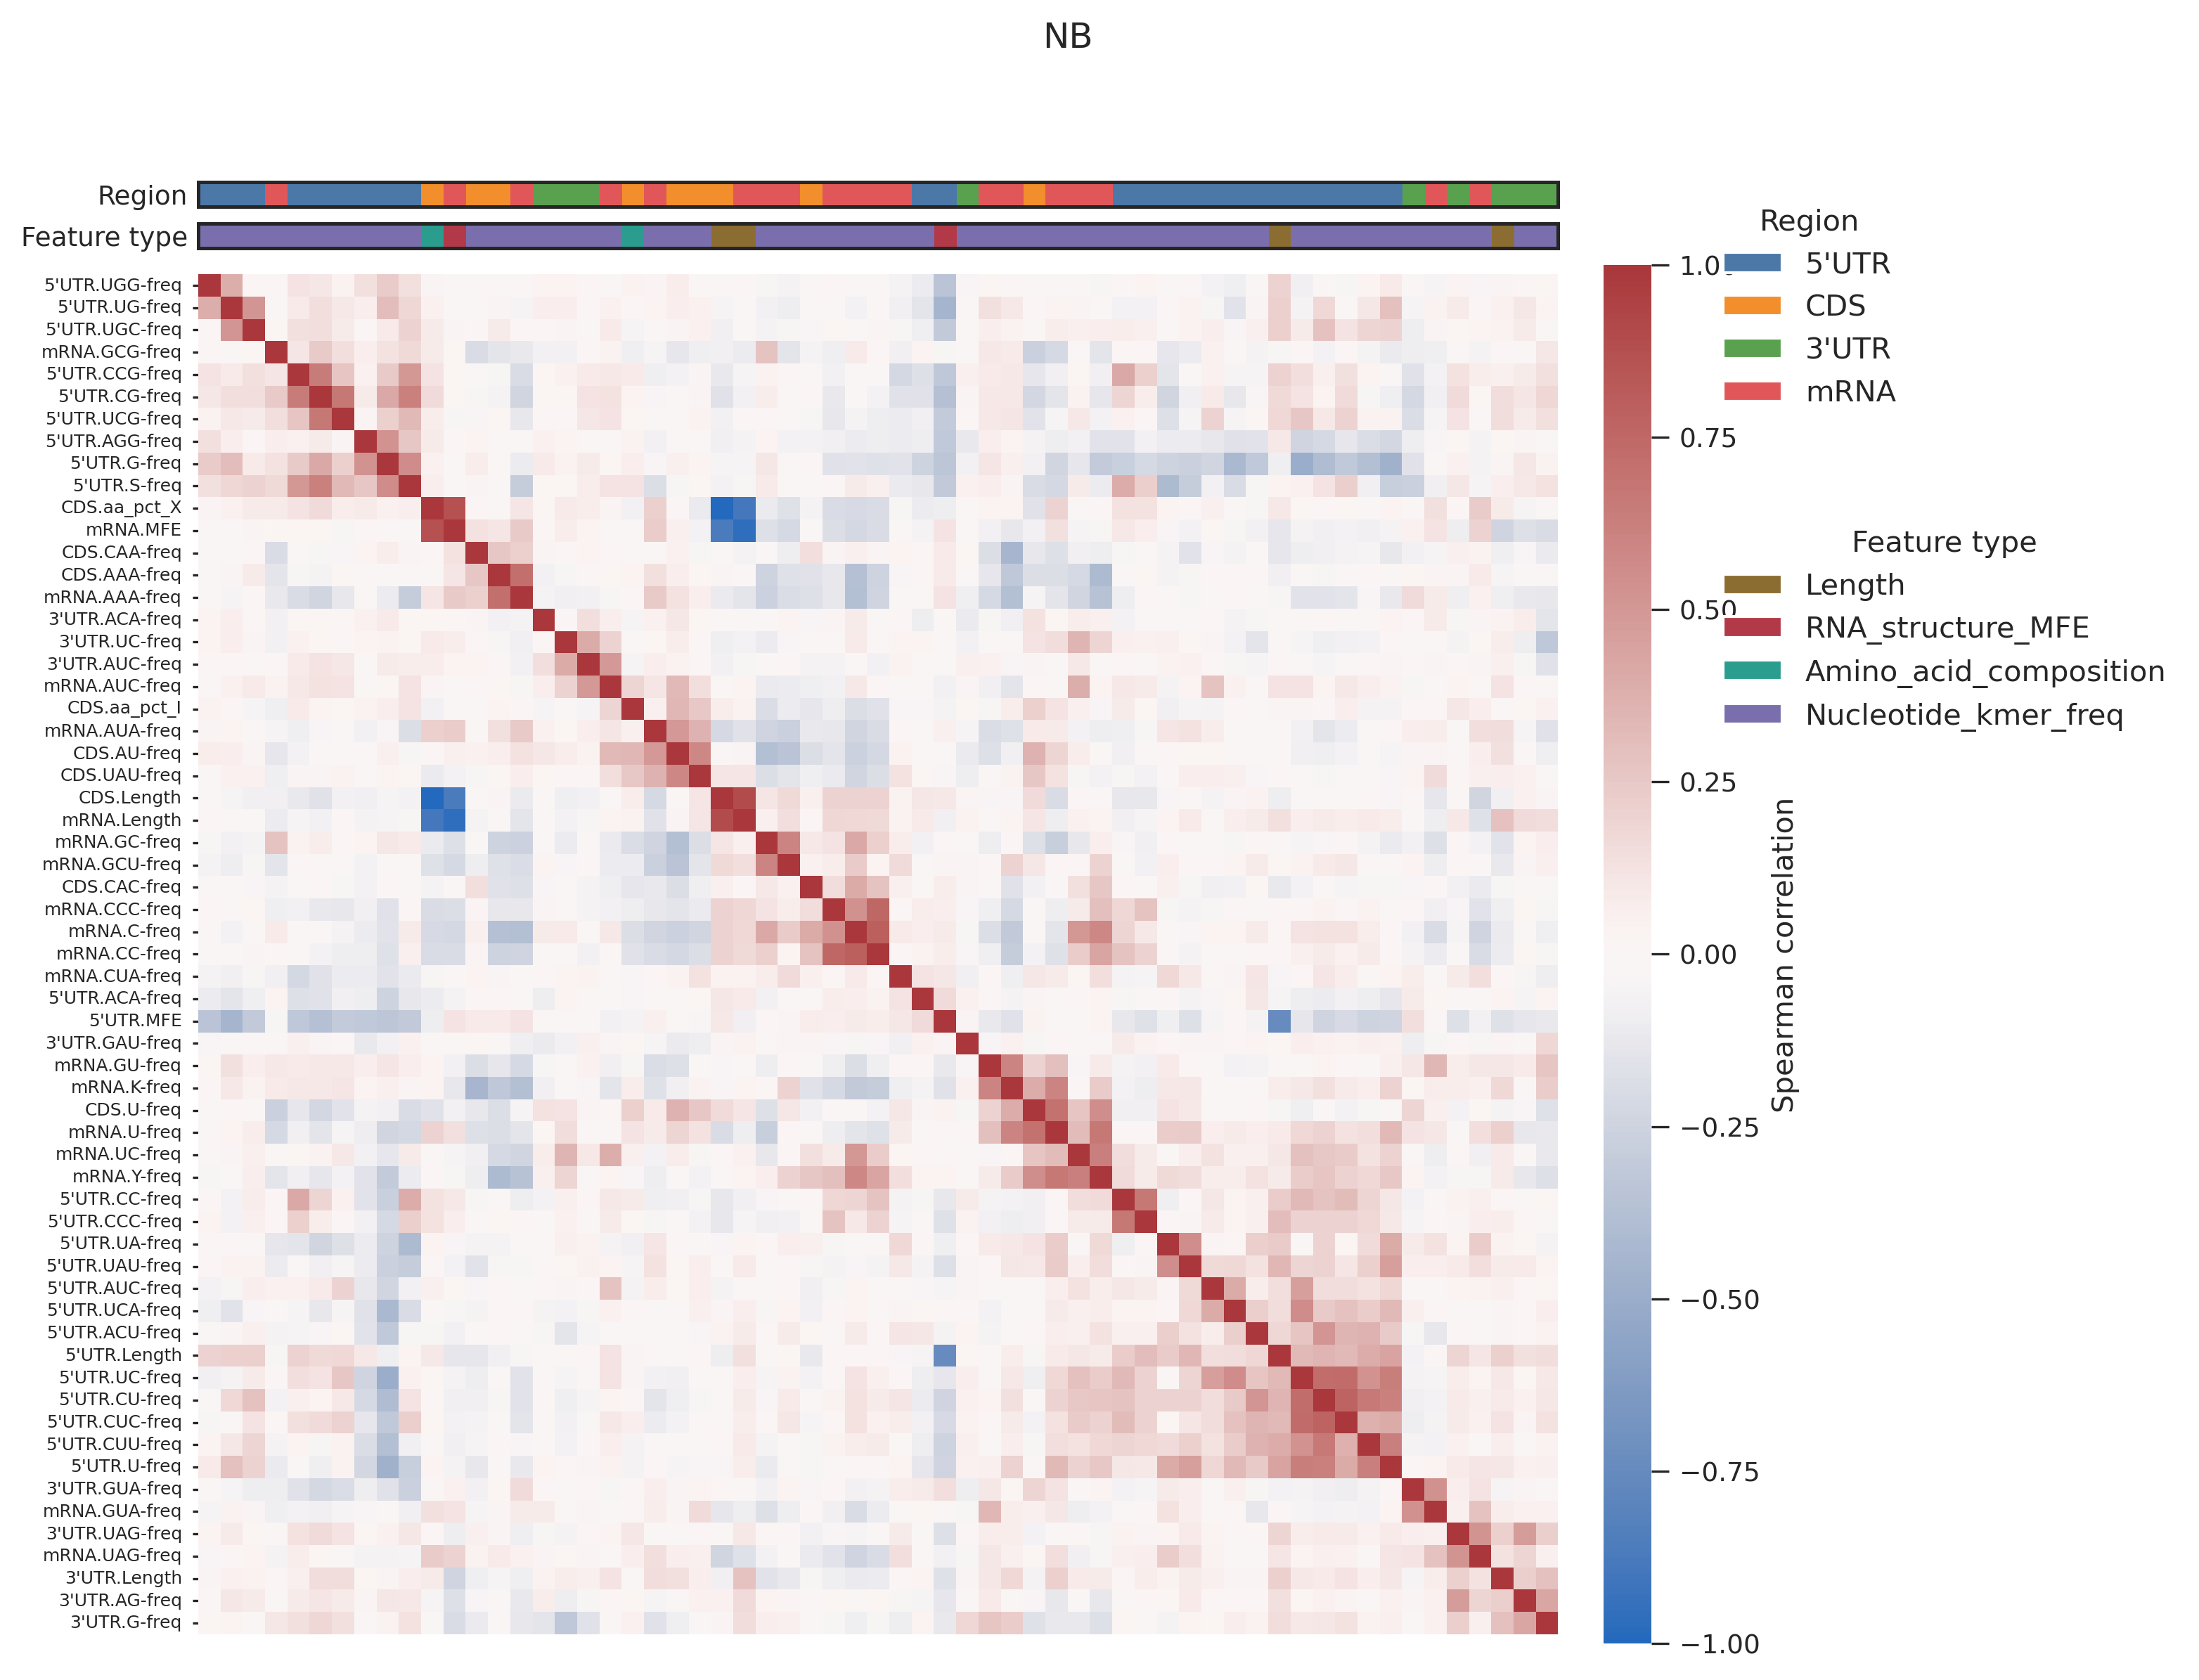

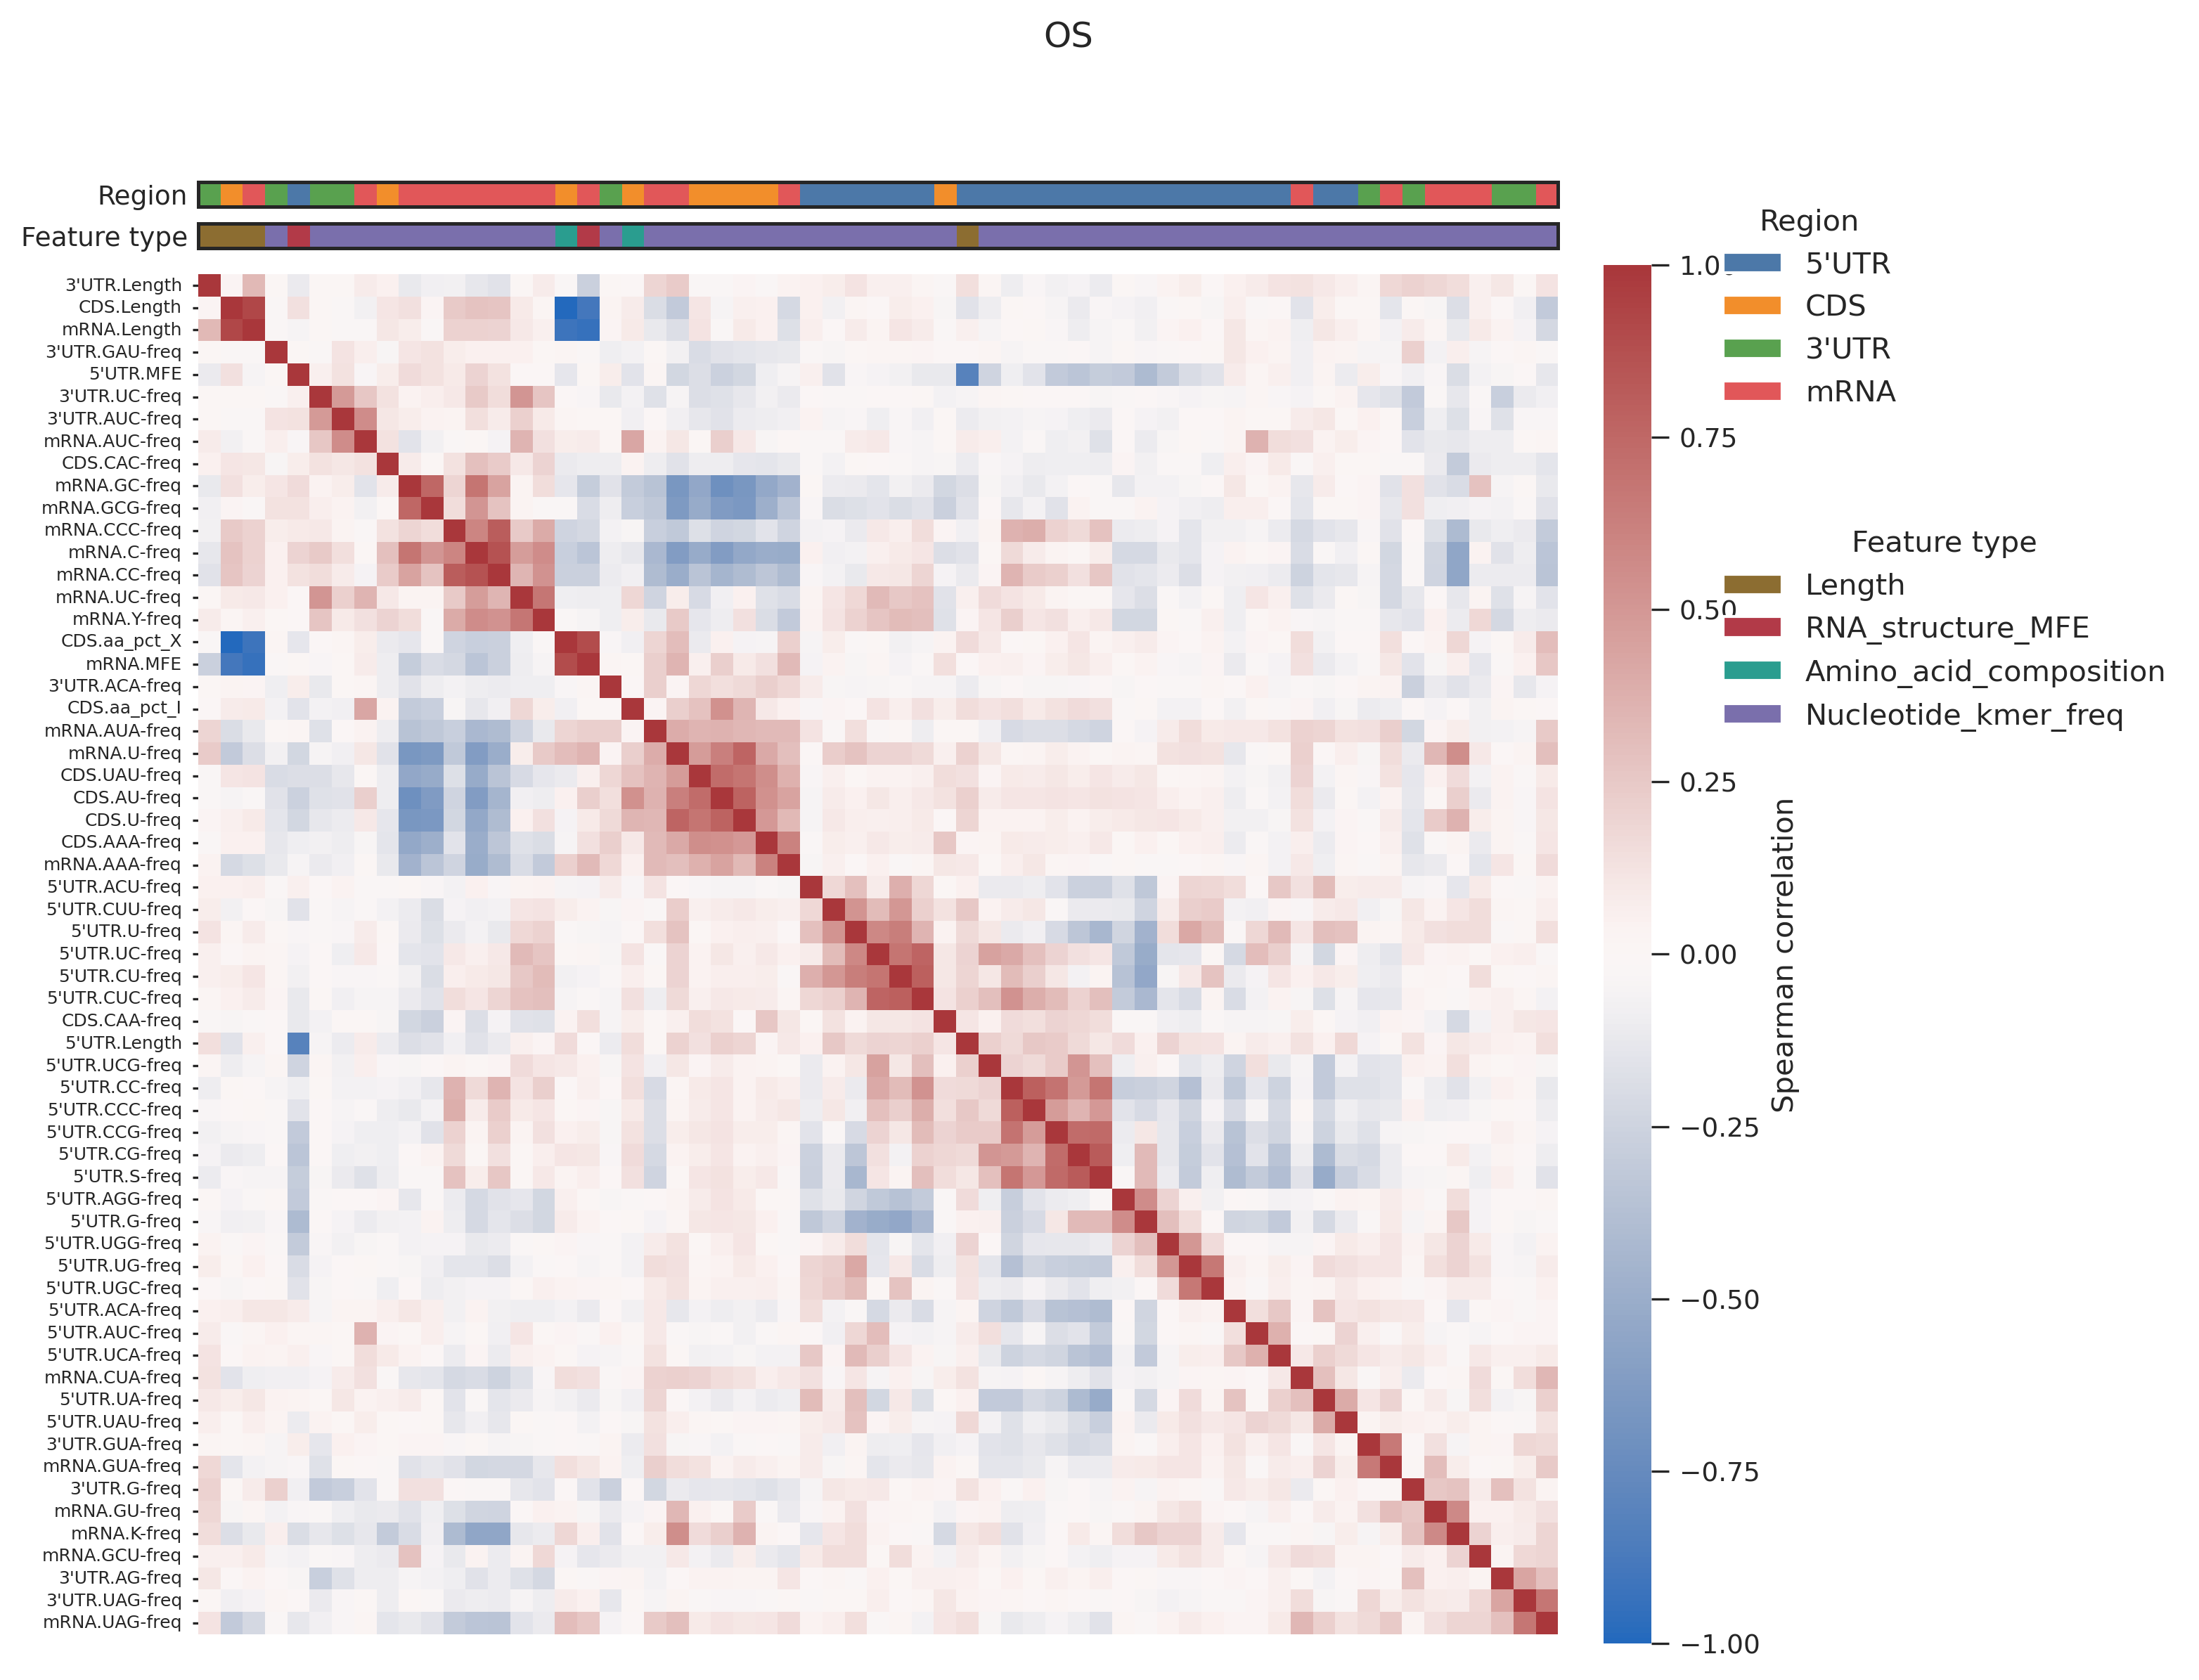

In [27]:
# ============================================
# Clustered candidate-feature correlation heatmaps
# Final layout
# ============================================

from matplotlib.patches import Patch

region_colors = {
    "5'UTR": "#4C78A8",
    "CDS": "#F28E2B",
    "3'UTR": "#59A14F",
    "mRNA": "#E15759",
}

feature_type_colors = {
    "Length": "#8C6D31",
    "RNA_structure_MFE": "#B23A48",
    "Amino_acid_composition": "#2A9D8F",
    "Nucleotide_kmer_freq": "#7A6FAC",
}

feature_meta_lookup = feature_metadata_df.set_index("Feature")

region_handles = [Patch(facecolor=region_colors[x], label=x) for x in region_colors]
type_handles = [Patch(facecolor=feature_type_colors[x], label=x) for x in feature_type_colors]

for species_key in SPECIES:

    species = SPECIES_INFO[species_key]["label"]
    order = feature_orders[species_key]
    corr_ordered = corr_matrices[species_key].loc[order, order].copy()

    region_values = [feature_meta_lookup.loc[f, "Region"] for f in order]
    type_values = [feature_meta_lookup.loc[f, "Feature_type"] for f in order]

    region_rgba = np.array([mpl.colors.to_rgba(region_colors[x]) for x in region_values])[None, :, :]
    type_rgba = np.array([mpl.colors.to_rgba(feature_type_colors[x]) for x in type_values])[None, :, :]

    # ----------------------------------------
    # Figure layout
    # heatmap | colorbar | annotation legends
    # ----------------------------------------

    fig = plt.figure(figsize=(11, 9), dpi=_PLOT_CFG["dpi"])

    gs = GridSpec(
        3, 3,
        figure=fig,
        width_ratios=[1, 0.035, 0.22],
        height_ratios=[0.018, 0.018, 1],
        hspace=0.035,
        wspace=0.08,
    )

    ax_region = fig.add_subplot(gs[0, 0])
    ax_type = fig.add_subplot(gs[1, 0])
    ax_heat = fig.add_subplot(gs[2, 0])
    ax_cbar = fig.add_subplot(gs[2, 1])
    ax_legend = fig.add_subplot(gs[:, 2])

    # ----------------------------------------
    # Annotation tracks
    # ----------------------------------------

    ax_region.imshow(region_rgba, aspect="auto")
    ax_type.imshow(type_rgba, aspect="auto")

    for ax, label in [(ax_region, "Region"), (ax_type, "Feature type")]:
        ax.set_xticks([])
        ax.set_yticks([0])
        ax.set_yticklabels([label])
        ax.tick_params(axis="y", length=0)

    # ----------------------------------------
    # Correlation heatmap
    # ----------------------------------------

    sns.heatmap(
        corr_ordered,
        cmap="vlag",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        xticklabels=False,
        yticklabels=True,
        cbar=True,
        cbar_ax=ax_cbar,
        cbar_kws={"label": "Spearman correlation"},
        ax=ax_heat,
    )

    ax_heat.set_xlabel("")
    ax_heat.set_ylabel("")
    ax_heat.tick_params(axis="y", labelrotation=0, labelsize=6, length=2)

    # ----------------------------------------
    # Annotation legends
    # ----------------------------------------

    ax_legend.axis("off")

    legend_region = ax_legend.legend(
        handles=region_handles,
        title="Region",
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(0, 1),
    )

    ax_legend.add_artist(legend_region)

    ax_legend.legend(
        handles=type_handles,
        title="Feature type",
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(0, 0.78),
    )

    # ----------------------------------------
    # Figure title
    # ----------------------------------------

    fig.suptitle(
        f"{species}",
        y=0.965,
    )

    plt.show()

In [28]:
# ============================================
# Strongest candidate-feature correlations
# ============================================

pair_tables = {}

for species_key in SPECIES:

    corr = corr_matrices[species_key]

    rows = []

    cols = corr.columns.tolist()

    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):

            f1 = cols[i]
            f2 = cols[j]

            r = corr.iloc[i, j]

            meta1 = feature_meta_lookup.loc[f1]
            meta2 = feature_meta_lookup.loc[f2]

            rows.append({
                "Feature_1": f1,
                "Feature_2": f2,
                "Correlation": r,
                "Abs_correlation": abs(r),

                "Region_1": meta1["Region"],
                "Region_2": meta2["Region"],

                "Feature_type_1": meta1["Feature_type"],
                "Feature_type_2": meta2["Feature_type"],

                "Same_region":
                    meta1["Region"] == meta2["Region"],

                "Same_feature_type":
                    meta1["Feature_type"] ==
                    meta2["Feature_type"],
            })

    pair_df = (
        pd.DataFrame(rows)
        .sort_values(
            "Abs_correlation",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    pair_tables[species_key] = pair_df

    print()
    print("=" * 60)
    print(species_key)
    print("=" * 60)

    print("\nTop positive correlations")
    display(
        pair_df
        .sort_values("Correlation", ascending=False)
        .head(15)
    )

    print("\nTop negative correlations")
    display(
        pair_df
        .sort_values("Correlation")
        .head(15)
    )


AT21

Top positive correlations


,Feature_1,Feature_2,Correlation,Abs_correlation,Region_1,Region_2,Feature_type_1,Feature_type_2,Same_region,Same_feature_type
3,CDS.Length,mRNA.Length,0.923965,0.923965,CDS,mRNA,Length,Length,False,True
5,CDS.aa_pct_X,mRNA.MFE,0.909533,0.909533,CDS,mRNA,Amino_acid_composition,RNA_structure_MFE,False,False
7,mRNA.C-freq,mRNA.CC-freq,0.809436,0.809436,mRNA,mRNA,Nucleotide_kmer_freq,Nucleotide_kmer_freq,True,True
8,5'UTR.CU-freq,5'UTR.CUC-freq,0.793638,0.793638,5'UTR,5'UTR,Nucleotide_kmer_freq,Nucleotide_kmer_freq,True,True
9,5'UTR.CU-freq,5'UTR.UC-freq,0.757204,0.757204,5'UTR,5'UTR,Nucleotide_kmer_freq,Nucleotide_kmer_freq,True,True
10,mRNA.CC-freq,mRNA.CCC-freq,0.743114,0.743114,mRNA,mRNA,Nucleotide_kmer_freq,Nucleotide_kmer_freq,True,True
11,5'UTR.CUC-freq,5'UTR.UC-freq,0.741687,0.741687,5'UTR,5'UTR,Nucleotide_kmer_freq,Nucleotide_kmer_freq,True,True
12,5'UTR.CU-freq,5'UTR.CUU-freq,0.700675,0.700675,5'UTR,5'UTR,Nucleotide_kmer_freq,Nucleotide_kmer_freq,True,True
13,5'UTR.U-freq,5'UTR.UC-freq,0.695651,0.695651,5'UTR,5'UTR,Nucleotide_kmer_freq,Nucleotide_kmer_freq,True,True
14,mRNA.UC-freq,mRNA.Y-freq,0.684392,0.684392,mRNA,mRNA,Nucleotide_kmer_freq,Nucleotide_kmer_freq,True,True



Top negative correlations


,Feature_1,Feature_2,Correlation,Abs_correlation,Region_1,Region_2,Feature_type_1,Feature_type_2,Same_region,Same_feature_type
0,CDS.Length,CDS.aa_pct_X,-1.000000,1.000000,CDS,CDS,Length,Amino_acid_composition,True,False
1,mRNA.Length,mRNA.MFE,-0.968306,0.968306,mRNA,mRNA,Length,RNA_structure_MFE,True,False
2,CDS.aa_pct_X,mRNA.Length,-0.923965,0.923965,CDS,mRNA,Amino_acid_composition,Length,False,False
4,CDS.Length,mRNA.MFE,-0.909533,0.909533,CDS,mRNA,Length,RNA_structure_MFE,False,False
6,5'UTR.Length,5'UTR.MFE,-0.818495,0.818495,5'UTR,5'UTR,Length,RNA_structure_MFE,True,False
39,CDS.CAA-freq,mRNA.K-freq,-0.492181,0.492181,CDS,mRNA,Nucleotide_kmer_freq,Nucleotide_kmer_freq,False,True
42,mRNA.C-freq,mRNA.K-freq,-0.474967,0.474967,mRNA,mRNA,Nucleotide_kmer_freq,Nucleotide_kmer_freq,True,True
44,5'UTR.G-freq,5'UTR.UC-freq,-0.459798,0.459798,5'UTR,5'UTR,Nucleotide_kmer_freq,Nucleotide_kmer_freq,True,True
46,mRNA.CC-freq,mRNA.K-freq,-0.452666,0.452666,mRNA,mRNA,Nucleotide_kmer_freq,Nucleotide_kmer_freq,True,True
52,5'UTR.CU-freq,5'UTR.G-freq,-0.435243,0.435243,5'UTR,5'UTR,Nucleotide_kmer_freq,Nucleotide_kmer_freq,True,True



NB21

Top positive correlations


...

,Feature_1,Feature_2,Correlation,Abs_correlation,Region_1,Region_2,Feature_type_1,Feature_type_2,Same_region,Same_feature_type
0,CDS.Length,CDS.aa_pct_X,-1.000000,1.000000,CDS,CDS,Length,Amino_acid_composition,True,False
1,mRNA.Length,mRNA.MFE,-0.963658,0.963658,mRNA,mRNA,Length,RNA_structure_MFE,True,False
3,CDS.aa_pct_X,mRNA.Length,-0.894180,0.894180,CDS,mRNA,Amino_acid_composition,Length,False,False
5,CDS.Length,mRNA.MFE,-0.874166,0.874166,CDS,mRNA,Length,RNA_structure_MFE,False,False
9,5'UTR.Length,5'UTR.MFE,-0.748432,0.748432,5'UTR,5'UTR,Length,RNA_structure_MFE,True,False
40,5'UTR.G-freq,5'UTR.UC-freq,-0.506475,0.506475,5'UTR,5'UTR,Nucleotide_kmer_freq,Nucleotide_kmer_freq,True,True
45,5'UTR.G-freq,5'UTR.U-freq,-0.470615,0.470615,5'UTR,5'UTR,Nucleotide_kmer_freq,Nucleotide_kmer_freq,True,True
49,5'UTR.MFE,5'UTR.UG-freq,-0.450090,0.450090,5'UTR,5'UTR,RNA_structure_MFE,Nucleotide_kmer_freq,True,False
51,CDS.CAA-freq,mRNA.K-freq,-0.441257,0.441257,CDS,mRNA,Nucleotide_kmer_freq,Nucleotide_kmer_freq,False,True
54,5'UTR.G-freq,5'UTR.UCA-freq,-0.419390,0.419390,5'UTR,5'UTR,Nucleotide_kmer_freq,Nucleotide_kmer_freq,True,True



OS21

Top positive correlations


,Feature_1,Feature_2,Correlation,Abs_correlation,Region_1,Region_2,Feature_type_1,Feature_type_2,Same_region,Same_feature_type
2,CDS.Length,mRNA.Length,0.921114,0.921114,CDS,mRNA,Length,Length,False,True
4,CDS.aa_pct_X,mRNA.MFE,0.891994,0.891994,CDS,mRNA,Amino_acid_composition,RNA_structure_MFE,False,False
6,mRNA.C-freq,mRNA.CC-freq,0.866815,0.866815,mRNA,mRNA,Nucleotide_kmer_freq,Nucleotide_kmer_freq,True,True
8,5'UTR.CG-freq,5'UTR.S-freq,0.815080,0.815080,5'UTR,5'UTR,Nucleotide_kmer_freq,Nucleotide_kmer_freq,True,True
9,mRNA.CC-freq,mRNA.CCC-freq,0.809995,0.809995,mRNA,mRNA,Nucleotide_kmer_freq,Nucleotide_kmer_freq,True,True
10,5'UTR.CU-freq,5'UTR.CUC-freq,0.792506,0.792506,5'UTR,5'UTR,Nucleotide_kmer_freq,Nucleotide_kmer_freq,True,True
11,5'UTR.CC-freq,5'UTR.CCC-freq,0.790576,0.790576,5'UTR,5'UTR,Nucleotide_kmer_freq,Nucleotide_kmer_freq,True,True
12,CDS.AU-freq,CDS.U-freq,0.776094,0.776094,CDS,CDS,Nucleotide_kmer_freq,Nucleotide_kmer_freq,True,True
13,CDS.U-freq,mRNA.U-freq,0.770432,0.770432,CDS,mRNA,Nucleotide_kmer_freq,Nucleotide_kmer_freq,False,True
14,5'UTR.CUC-freq,5'UTR.UC-freq,0.767943,0.767943,5'UTR,5'UTR,Nucleotide_kmer_freq,Nucleotide_kmer_freq,True,True



Top negative correlations


,Feature_1,Feature_2,Correlation,Abs_correlation,Region_1,Region_2,Feature_type_1,Feature_type_2,Same_region,Same_feature_type
0,CDS.Length,CDS.aa_pct_X,-1.000000,1.000000,CDS,CDS,Length,Amino_acid_composition,True,False
1,mRNA.Length,mRNA.MFE,-0.943709,0.943709,mRNA,mRNA,Length,RNA_structure_MFE,True,False
3,CDS.aa_pct_X,mRNA.Length,-0.921114,0.921114,CDS,mRNA,Amino_acid_composition,Length,False,False
5,CDS.Length,mRNA.MFE,-0.891994,0.891994,CDS,mRNA,Length,RNA_structure_MFE,False,False
7,5'UTR.Length,5'UTR.MFE,-0.817939,0.817939,5'UTR,5'UTR,Length,RNA_structure_MFE,True,False
19,CDS.AU-freq,mRNA.GC-freq,-0.716397,0.716397,CDS,mRNA,Nucleotide_kmer_freq,Nucleotide_kmer_freq,False,True
28,mRNA.GC-freq,mRNA.U-freq,-0.663692,0.663692,mRNA,mRNA,Nucleotide_kmer_freq,Nucleotide_kmer_freq,True,True
30,CDS.U-freq,mRNA.GC-freq,-0.656859,0.656859,CDS,mRNA,Nucleotide_kmer_freq,Nucleotide_kmer_freq,False,True
31,CDS.U-freq,mRNA.GCG-freq,-0.655901,0.655901,CDS,mRNA,Nucleotide_kmer_freq,Nucleotide_kmer_freq,False,True
33,mRNA.GCG-freq,mRNA.U-freq,-0.633481,0.633481,mRNA,mRNA,Nucleotide_kmer_freq,Nucleotide_kmer_freq,True,True


In [31]:
# ============================================
# Candidate feature association with PR value
# Spearman correlation
# ============================================

association_results = {}
association_rows = []

for species_key in SPECIES:

    species = SPECIES_INFO[species_key]["label"]
    df = candidate_master_df[candidate_master_df["Species"] == species].copy()

    for feature in candidate_features:

        r, p = stats.spearmanr(df[feature], df["observed_raw"], nan_policy="omit")
        meta = feature_meta_lookup.loc[feature]

        association_rows.append({
            "Species": species,
            "Species_key": species_key,
            "Feature": feature,
            "Spearman_r": r,
            "Abs_r": abs(r),
            "P_value": p,
            "Region": meta["Region"],
            "Feature_type": meta["Feature_type"],
        })

association_df = pd.DataFrame(association_rows)

for species_key in SPECIES:

    species = SPECIES_INFO[species_key]["label"]
    result = association_df[association_df["Species"] == species].sort_values("Abs_r", ascending=False).reset_index(drop=True)
    association_results[species_key] = result

    print("\n" + "=" * 60)
    print(species_key)
    print("=" * 60)

    print("\nTop positive associations")
    display(result.sort_values("Spearman_r", ascending=False).head(15))

    print("\nTop negative associations")
    display(result.sort_values("Spearman_r").head(15))


AT21

Top positive associations


,Species,Species_key,Feature,Spearman_r,Abs_r,P_value,Region,Feature_type
2,AT,AT21,5'UTR.MFE,0.171073,0.171073,6.184128e-48,5'UTR,RNA_structure_MFE
17,AT,AT21,mRNA.GC-freq,0.094744,0.094744,1.106133e-15,mRNA,Nucleotide_kmer_freq
18,AT,AT21,mRNA.MFE,0.091073,0.091073,1.332522e-14,mRNA,RNA_structure_MFE
20,AT,AT21,CDS.aa_pct_X,0.090525,0.090525,1.915972e-14,CDS,Amino_acid_composition
28,AT,AT21,5'UTR.ACA-freq,0.074827,0.074827,2.543590e-10,5'UTR,Nucleotide_kmer_freq
33,AT,AT21,mRNA.GU-freq,0.058894,0.058894,6.523104e-07,mRNA,Nucleotide_kmer_freq
38,AT,AT21,CDS.CAC-freq,0.049403,0.049403,3.016330e-05,CDS,Nucleotide_kmer_freq
40,AT,AT21,mRNA.GCG-freq,0.045997,0.045997,1.026508e-04,mRNA,Nucleotide_kmer_freq
43,AT,AT21,3'UTR.GUA-freq,0.042946,0.042946,2.874446e-04,3'UTR,Nucleotide_kmer_freq
44,AT,AT21,5'UTR.UA-freq,0.040237,0.040237,6.801669e-04,5'UTR,Nucleotide_kmer_freq



Top negative associations


,Species,Species_key,Feature,Spearman_r,Abs_r,P_value,Region,Feature_type
0,AT,AT21,CDS.U-freq,-0.206221,0.206221,2.705246e-69,CDS,Nucleotide_kmer_freq
1,AT,AT21,CDS.AU-freq,-0.205146,0.205146,1.408933e-68,CDS,Nucleotide_kmer_freq
3,AT,AT21,CDS.UAU-freq,-0.145280,0.145280,6.467855e-35,CDS,Nucleotide_kmer_freq
4,AT,AT21,5'UTR.S-freq,-0.140297,0.140297,1.181925e-32,5'UTR,Nucleotide_kmer_freq
5,AT,AT21,5'UTR.Length,-0.132556,0.132556,2.670718e-29,5'UTR,Length
6,AT,AT21,mRNA.Y-freq,-0.123443,0.123443,1.336701e-25,mRNA,Nucleotide_kmer_freq
7,AT,AT21,CDS.aa_pct_I,-0.121213,0.121213,9.781828e-25,CDS,Amino_acid_composition
8,AT,AT21,mRNA.Length,-0.118827,0.118827,7.907029e-24,mRNA,Length
9,AT,AT21,5'UTR.CU-freq,-0.118530,0.118530,1.022310e-23,5'UTR,Nucleotide_kmer_freq
10,AT,AT21,5'UTR.CUC-freq,-0.115111,0.115111,1.884276e-22,5'UTR,Nucleotide_kmer_freq



NB21

Top positive associations


...

,Species,Species_key,Feature,Spearman_r,Abs_r,P_value,Region,Feature_type
0,NB,NB21,mRNA.Length,-0.455792,0.455792,2.358627e-274,mRNA,Length
3,NB,NB21,CDS.Length,-0.429017,0.429017,6.537236e-240,CDS,Length
4,NB,NB21,mRNA.C-freq,-0.199332,0.199332,2.387992e-49,mRNA,Nucleotide_kmer_freq
5,NB,NB21,mRNA.CC-freq,-0.191783,0.191783,9.559202e-46,mRNA,Nucleotide_kmer_freq
6,NB,NB21,mRNA.CCC-freq,-0.170230,0.170230,2.851344e-36,mRNA,Nucleotide_kmer_freq
7,NB,NB21,CDS.U-freq,-0.132495,0.132495,1.671336e-22,CDS,Nucleotide_kmer_freq
8,NB,NB21,mRNA.Y-freq,-0.125194,0.125194,3.033417e-20,mRNA,Nucleotide_kmer_freq
9,NB,NB21,mRNA.UC-freq,-0.105759,0.105759,7.368370e-15,mRNA,Nucleotide_kmer_freq
12,NB,NB21,5'UTR.Length,-0.095704,0.095704,1.993770e-12,5'UTR,Length
13,NB,NB21,5'UTR.UAU-freq,-0.084468,0.084468,5.441000e-10,5'UTR,Nucleotide_kmer_freq



OS21

Top positive associations


,Species,Species_key,Feature,Spearman_r,Abs_r,P_value,Region,Feature_type
1,OS,OS21,CDS.aa_pct_X,0.195089,0.195089,9.409930e-49,CDS,Amino_acid_composition
3,OS,OS21,mRNA.MFE,0.183228,0.183228,4.066315e-43,mRNA,RNA_structure_MFE
13,OS,OS21,5'UTR.MFE,0.073845,0.073845,3.616477e-08,5'UTR,RNA_structure_MFE
14,OS,OS21,mRNA.K-freq,0.072978,0.072978,5.217975e-08,mRNA,Nucleotide_kmer_freq
18,OS,OS21,3'UTR.AG-freq,0.065712,0.065712,9.560175e-07,3'UTR,Nucleotide_kmer_freq
20,OS,OS21,mRNA.UAG-freq,0.065123,0.065123,1.194806e-06,mRNA,Nucleotide_kmer_freq
21,OS,OS21,3'UTR.UAG-freq,0.062105,0.062105,3.639913e-06,3'UTR,Nucleotide_kmer_freq
23,OS,OS21,5'UTR.ACU-freq,0.061460,0.061460,4.588150e-06,5'UTR,Nucleotide_kmer_freq
24,OS,OS21,mRNA.GUA-freq,0.060757,0.060757,5.890720e-06,mRNA,Nucleotide_kmer_freq
29,OS,OS21,CDS.CAA-freq,0.051110,0.051110,1.390033e-04,CDS,Nucleotide_kmer_freq



Top negative associations


,Species,Species_key,Feature,Spearman_r,Abs_r,P_value,Region,Feature_type
0,OS,OS21,mRNA.Length,-0.219563,0.219563,1.383842e-61,mRNA,Length
2,OS,OS21,CDS.Length,-0.195089,0.195089,9.409930e-49,CDS,Length
4,OS,OS21,mRNA.UC-freq,-0.175935,0.175935,7.738956e-40,mRNA,Nucleotide_kmer_freq
5,OS,OS21,mRNA.Y-freq,-0.160176,0.160176,3.151925e-33,mRNA,Nucleotide_kmer_freq
6,OS,OS21,mRNA.CCC-freq,-0.133709,0.133709,1.440430e-23,mRNA,Nucleotide_kmer_freq
7,OS,OS21,mRNA.CC-freq,-0.126671,0.126671,2.680214e-21,mRNA,Nucleotide_kmer_freq
8,OS,OS21,3'UTR.UC-freq,-0.120731,0.120731,1.766548e-19,3'UTR,Nucleotide_kmer_freq
9,OS,OS21,mRNA.C-freq,-0.110150,0.110150,1.862120e-16,mRNA,Nucleotide_kmer_freq
10,OS,OS21,CDS.U-freq,-0.108690,0.108690,4.626482e-16,CDS,Nucleotide_kmer_freq
11,OS,OS21,CDS.aa_pct_I,-0.084960,0.084960,2.289420e-10,CDS,Amino_acid_composition


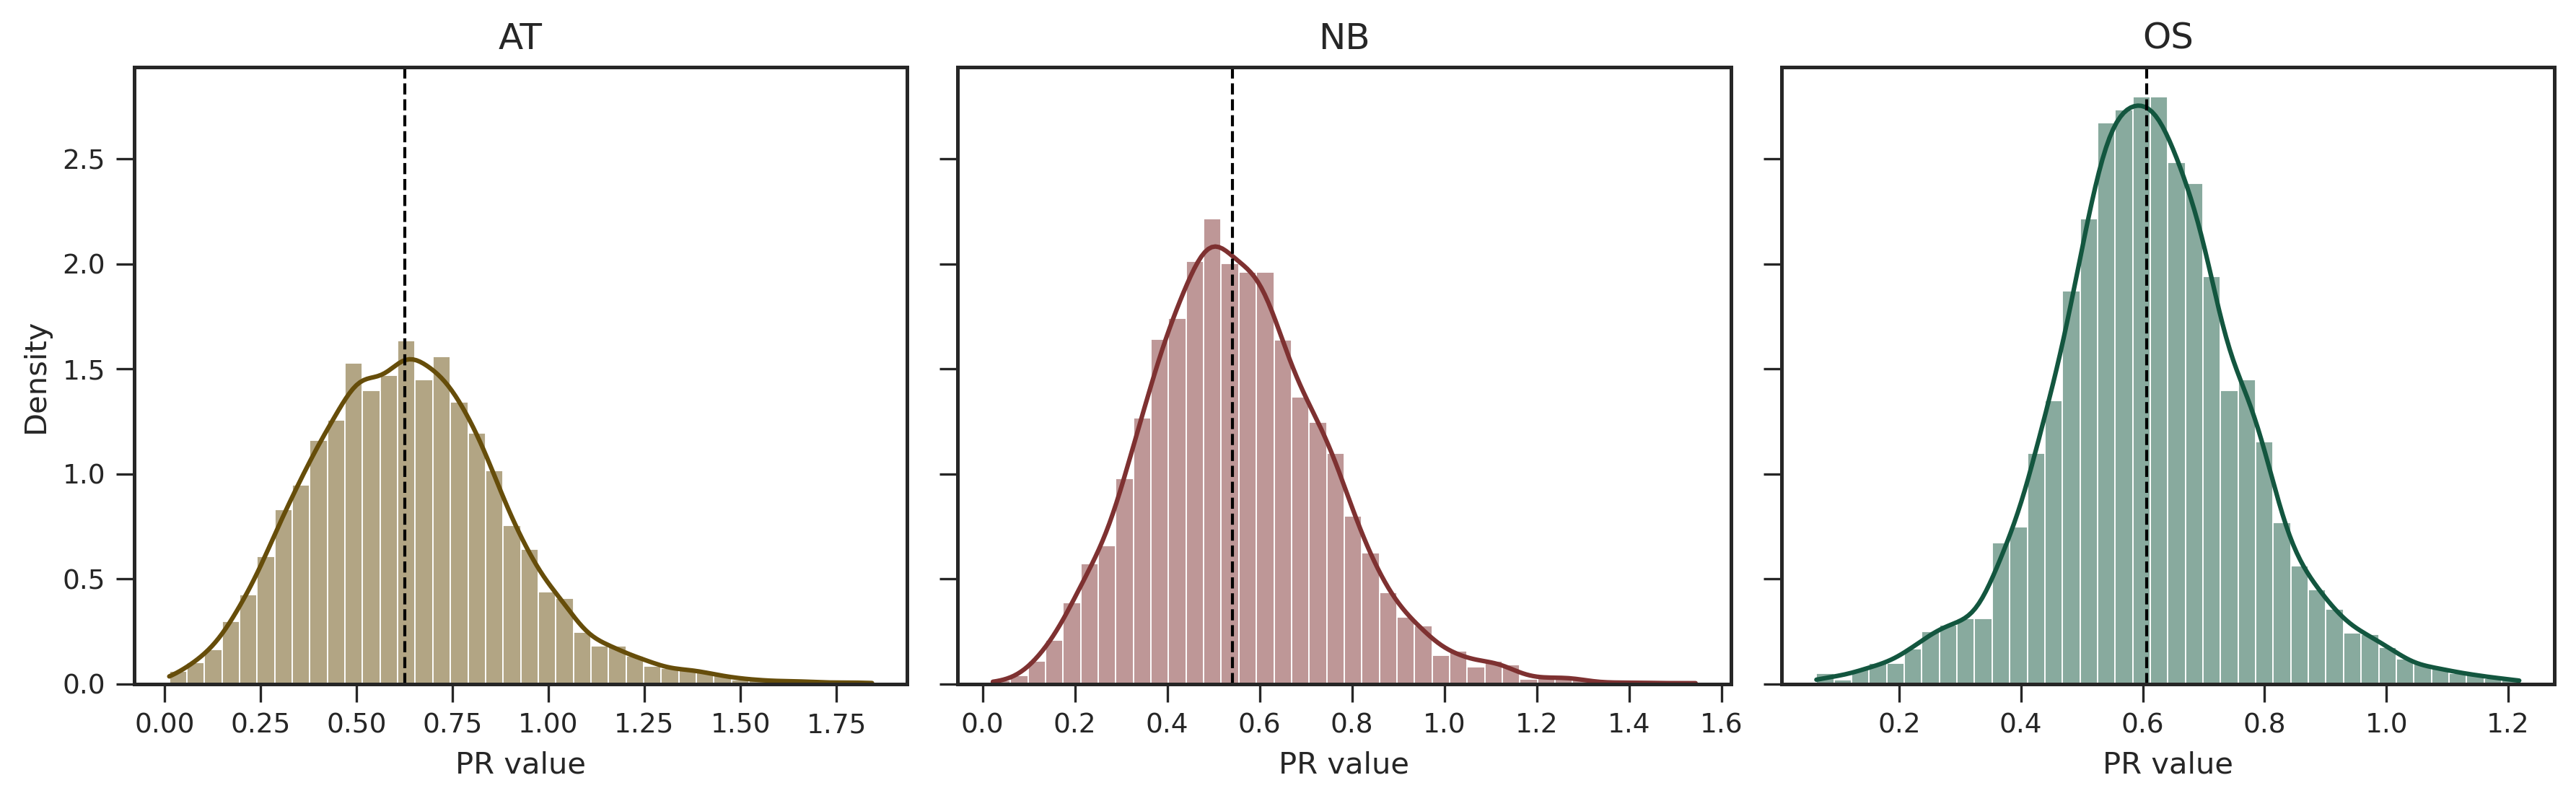

PR value summary


,Species,n,Mean,Std,Median,Q1,Q3,Min,Max,Skew,Kurtosis
0,AT,7126,0.637672,0.258276,0.626653,0.455793,0.796480,0.012537,1.842711,0.508763,0.665669
1,NB,5381,0.555717,0.198415,0.541475,0.417822,0.677982,0.022537,1.543504,0.510247,0.658549
2,OS,5552,0.611310,0.160404,0.606808,0.514014,0.706001,0.064318,1.218101,0.126651,0.765733


In [32]:
# ============================================
# PR value distribution
# ============================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 3.8),
    dpi=_PLOT_CFG["dpi"],
    sharey=True,
)

pr_summary = []

for ax, species_key in zip(axes, SPECIES):

    species = SPECIES_INFO[species_key]["label"]

    df = candidate_master_df[
        candidate_master_df["Species"] == species
    ]

    values = df["observed_raw"]

    sns.histplot(
        values,
        bins=40,
        stat="density",
        kde=True,
        color=SPECIES_INFO[species_key]["color"],
        edgecolor=None,
        ax=ax,
    )

    ax.axvline(
        values.median(),
        color="black",
        linestyle="--",
        linewidth=1,
    )

    format_axis(
        ax,
        xlabel="PR value",
        ylabel="Density" if ax is axes[0] else None,
    )

    ax.set_title(species)

    pr_summary.append({

        "Species": species,

        "n": len(values),

        "Mean": values.mean(),
        "Std": values.std(),

        "Median": values.median(),

        "Q1": values.quantile(0.25),
        "Q3": values.quantile(0.75),

        "Min": values.min(),
        "Max": values.max(),

        "Skew": stats.skew(values),
        "Kurtosis": stats.kurtosis(values),

    })

plt.tight_layout()
plt.show()

pr_summary_df = pd.DataFrame(pr_summary)

print("PR value summary")
display(pr_summary_df)

In [35]:
# ============================================
# Top and Bottom PR groups
# ============================================

group_frames = []
group_summary = []

for species_key in SPECIES:

    species = SPECIES_INFO[species_key]["label"]

    df = candidate_master_df[
        candidate_master_df["Species"] == species
    ].copy()

    q10 = df["observed_raw"].quantile(0.10)
    q90 = df["observed_raw"].quantile(0.90)

    df["PR_group"] = pd.Series(pd.NA, index=df.index, dtype="string")
    df.loc[df["observed_raw"] <= q10, "PR_group"] = "Bottom"
    df.loc[df["observed_raw"] >= q90, "PR_group"] = "Top"

    df = df[df["PR_group"].notna()].copy()

    group_frames.append(df)

    group_summary.append({
        "Species": species,
        "Bottom_cutoff": q10,
        "Top_cutoff": q90,
        "Bottom_n": (df["PR_group"] == "Bottom").sum(),
        "Top_n": (df["PR_group"] == "Top").sum(),
    })

candidate_group_df = pd.concat(group_frames, ignore_index=True)
group_summary_df = pd.DataFrame(group_summary)

print("Top / Bottom PR groups")
display(group_summary_df)

print("\nCombined dataset")
print(candidate_group_df.shape)

display(
    candidate_group_df[
        ["Species", "var_id", "observed_raw", "PR_group"]
    ].head()
)

Top / Bottom PR groups


,Species,Bottom_cutoff,Top_cutoff,Bottom_n,Top_n
0,AT,0.317432,0.959503,713,714
1,NB,0.318706,0.806749,539,539
2,OS,0.423435,0.806267,556,556



Combined dataset
(3617, 71)


,Species,var_id,observed_raw,PR_group
0,AT,AT2G23340.1.9937988.9938873,1.047809,Top
1,AT,AT3G14430.1.4824826.4824197,1.353368,Top
2,AT,AT3G16080.1.5454849.5455854,1.008269,Top
3,AT,AT1G14980.1.5166682.5165731,1.153191,Top
4,AT,AT1G70600.1.26621656.26621003,0.970284,Top


In [36]:
# ============================================
# Candidate features: Top vs Bottom PR
# Mann–Whitney U + Cliff's delta + FDR
# ============================================

from statsmodels.stats.multitest import multipletests

top_bottom_rows = []

for species_key in SPECIES:

    species = SPECIES_INFO[species_key]["label"]
    df = candidate_group_df[candidate_group_df["Species"] == species]

    for feature in candidate_features:

        top = df.loc[df["PR_group"] == "Top", feature].dropna().to_numpy(dtype=float)
        bottom = df.loc[df["PR_group"] == "Bottom", feature].dropna().to_numpy(dtype=float)

        u_stat, p_value = stats.mannwhitneyu(top, bottom, alternative="two-sided")
        cliff_delta = (2 * u_stat) / (len(top) * len(bottom)) - 1

        meta = feature_meta_lookup.loc[feature]

        top_bottom_rows.append({
            "Species": species,
            "Species_key": species_key,
            "Feature": feature,
            "Region": meta["Region"],
            "Feature_type": meta["Feature_type"],
            "Top_n": len(top),
            "Bottom_n": len(bottom),
            "Top_median": np.median(top),
            "Bottom_median": np.median(bottom),
            "Median_difference": np.median(top) - np.median(bottom),
            "Cliff_delta": cliff_delta,
            "Abs_Cliff_delta": abs(cliff_delta),
            "P_value": p_value,
        })

top_bottom_stats_df = pd.DataFrame(top_bottom_rows)

for species in top_bottom_stats_df["Species"].unique():
    mask = top_bottom_stats_df["Species"] == species
    top_bottom_stats_df.loc[mask, "FDR"] = multipletests(top_bottom_stats_df.loc[mask, "P_value"], method="fdr_bh")[1]

top_bottom_stats_df["Direction"] = np.select(
    [top_bottom_stats_df["Cliff_delta"] > 0, top_bottom_stats_df["Cliff_delta"] < 0],
    ["Higher in Top", "Higher in Bottom"],
    default="No difference",
)

top_bottom_stats_df = top_bottom_stats_df.sort_values(["Species", "Abs_Cliff_delta"], ascending=[True, False]).reset_index(drop=True)

print("Top vs Bottom PR feature comparison")
print("-----------------------------------")
print(top_bottom_stats_df.shape)

for species_key in SPECIES:
    species = SPECIES_INFO[species_key]["label"]
    result = top_bottom_stats_df[top_bottom_stats_df["Species"] == species]

    print("\n" + "=" * 60)
    print(species_key)
    print("=" * 60)
    display(result[[
        "Feature", "Region", "Feature_type",
        "Top_median", "Bottom_median", "Median_difference",
        "Cliff_delta", "Abs_Cliff_delta", "P_value", "FDR", "Direction"
    ]].head(15))

Top vs Bottom PR feature comparison
-----------------------------------
(183, 15)

AT21


,Feature,Region,Feature_type,Top_median,Bottom_median,Median_difference,Cliff_delta,Abs_Cliff_delta,P_value,FDR,Direction
0,CDS.U-freq,CDS,Nucleotide_kmer_freq,238.461538,257.142857,-18.681319,-0.349315,0.349315,3.182727e-30,1.941463e-28,Higher in Bottom
1,CDS.AU-freq,CDS,Nucleotide_kmer_freq,55.045872,64.000000,-8.954128,-0.339161,0.339161,1.375668e-28,4.195787e-27,Higher in Bottom
2,5'UTR.MFE,5'UTR,RNA_structure_MFE,-6.900000,-13.060000,6.160000,0.266725,0.266725,2.503523e-18,5.090497e-17,Higher in Top
3,5'UTR.S-freq,5'UTR,Nucleotide_kmer_freq,388.321995,431.034483,-42.712487,-0.246000,0.246000,8.606769e-16,1.098576e-14,Higher in Bottom
4,mRNA.Y-freq,mRNA,Nucleotide_kmer_freq,483.333251,497.931034,-14.597783,-0.245841,0.245841,9.004724e-16,1.098576e-14,Higher in Bottom
5,CDS.UAU-freq,CDS,Nucleotide_kmer_freq,8.547009,10.822511,-2.275502,-0.233951,0.233951,1.949424e-14,1.981915e-13,Higher in Bottom
6,5'UTR.CUU-freq,5'UTR,Nucleotide_kmer_freq,14.185111,24.390244,-10.205133,-0.208131,0.208131,2.896816e-12,2.524368e-11,Higher in Bottom
7,mRNA.UC-freq,mRNA,Nucleotide_kmer_freq,69.698451,73.783359,-4.084909,-0.198695,0.198695,8.144933e-11,5.520454e-10,Higher in Bottom
8,5'UTR.Length,5'UTR,Length,53.000000,63.000000,-10.000000,-0.198029,0.198029,9.385564e-11,5.725194e-10,Higher in Bottom
9,5'UTR.CUC-freq,5'UTR,Nucleotide_kmer_freq,11.634199,22.222222,-10.588023,-0.197059,0.197059,2.961842e-11,2.258405e-10,Higher in Bottom



NB21


,Feature,Region,Feature_type,Top_median,Bottom_median,Median_difference,Cliff_delta,Abs_Cliff_delta,P_value,FDR,Direction
61,mRNA.Length,mRNA,Length,534.000000,779.000000,-245.000000,-0.728612,0.728612,2.945511e-95,1.796761e-93,Higher in Bottom
62,mRNA.MFE,mRNA,RNA_structure_MFE,-190.919998,-289.510010,98.590012,0.720378,0.720378,3.691153e-93,1.125802e-91,Higher in Top
63,CDS.Length,CDS,Length,312.000000,507.000000,-195.000000,-0.702920,0.702920,8.456885e-89,1.289675e-87,Higher in Bottom
64,CDS.aa_pct_X,CDS,Amino_acid_composition,0.009615,0.005917,0.003698,0.702920,0.702920,8.456885e-89,1.289675e-87,Higher in Top
65,mRNA.C-freq,mRNA,Nucleotide_kmer_freq,182.310469,198.402130,-16.091661,-0.366868,0.366868,1.873659e-25,2.285864e-24,Higher in Bottom
66,mRNA.CC-freq,mRNA,Nucleotide_kmer_freq,35.514019,41.841004,-6.326985,-0.297827,0.297827,2.574033e-17,2.616934e-16,Higher in Bottom
67,mRNA.AAA-freq,mRNA,Nucleotide_kmer_freq,32.857143,26.634383,6.222760,0.238802,0.238802,1.145802e-11,9.984844e-11,Higher in Top
68,5'UTR.Length,5'UTR,Length,55.000000,64.000000,-9.000000,-0.231326,0.231326,4.867069e-11,3.298791e-10,Higher in Bottom
69,5'UTR.CUC-freq,5'UTR,Nucleotide_kmer_freq,14.925373,26.315789,-11.390416,-0.229594,0.229594,2.968124e-11,2.263194e-10,Higher in Bottom
70,mRNA.UC-freq,mRNA,Nucleotide_kmer_freq,56.818182,61.141304,-4.323123,-0.227006,0.227006,1.106523e-10,6.749790e-10,Higher in Bottom



OS21


,Feature,Region,Feature_type,Top_median,Bottom_median,Median_difference,Cliff_delta,Abs_Cliff_delta,P_value,FDR,Direction
122,mRNA.Length,mRNA,Length,622.500000,795.000000,-172.500000,-0.399452,0.399452,9.253764e-31,5.644796e-29,Higher in Bottom
123,CDS.Length,CDS,Length,336.000000,474.000000,-138.000000,-0.348626,0.348626,7.982859e-24,1.623181e-22,Higher in Bottom
124,CDS.aa_pct_X,CDS,Amino_acid_composition,0.008929,0.006329,0.002599,0.348626,0.348626,7.982859e-24,1.623181e-22,Higher in Top
125,mRNA.UC-freq,mRNA,Nucleotide_kmer_freq,62.960510,70.037225,-7.076715,-0.342551,0.342551,4.691726e-23,7.154882e-22,Higher in Bottom
126,mRNA.MFE,mRNA,RNA_structure_MFE,-271.660004,-329.565002,57.904999,0.340407,0.340407,8.689941e-23,1.060173e-21,Higher in Top
127,mRNA.Y-freq,mRNA,Nucleotide_kmer_freq,491.262004,506.970355,-15.708351,-0.315405,0.315405,8.673440e-20,8.817998e-19,Higher in Bottom
128,CDS.U-freq,CDS,Nucleotide_kmer_freq,172.248804,202.521764,-30.272961,-0.270839,0.270839,5.364579e-15,4.674847e-14,Higher in Bottom
129,mRNA.CCC-freq,mRNA,Nucleotide_kmer_freq,12.155257,15.509193,-3.353936,-0.248263,0.248263,7.705961e-13,5.875795e-12,Higher in Bottom
130,mRNA.CC-freq,mRNA,Nucleotide_kmer_freq,65.954547,73.013937,-7.059390,-0.212195,0.212195,9.060627e-10,6.141092e-09,Higher in Bottom
131,3'UTR.UC-freq,3'UTR,Nucleotide_kmer_freq,58.252427,64.935065,-6.682638,-0.209377,0.209377,1.504926e-09,9.056268e-09,Higher in Bottom


Cross-species effect summary
----------------------------


,Feature,Region,Feature_type,AT,NB,OS,Mean_delta,Mean_abs_delta,Min_abs_delta,Same_direction,FDR_all
0,mRNA.Length,mRNA,Length,-0.177480,-0.728612,-0.399452,-0.435181,0.435181,0.177480,True,True
1,mRNA.MFE,mRNA,RNA_structure_MFE,0.131843,0.720378,0.340407,0.397543,0.397543,0.131843,True,True
2,CDS.aa_pct_X,CDS,Amino_acid_composition,0.131967,0.702920,0.348626,0.394504,0.394504,0.131967,True,True
3,CDS.Length,CDS,Length,-0.131967,-0.702920,-0.348626,-0.394504,0.394504,0.131967,True,True
4,CDS.U-freq,CDS,Nucleotide_kmer_freq,-0.349315,-0.173726,-0.270839,-0.264627,0.264627,0.173726,True,True
5,mRNA.Y-freq,mRNA,Nucleotide_kmer_freq,-0.245841,-0.217120,-0.315405,-0.259455,0.259455,0.217120,True,True
6,mRNA.UC-freq,mRNA,Nucleotide_kmer_freq,-0.198695,-0.227006,-0.342551,-0.256084,0.256084,0.198695,True,True
7,mRNA.C-freq,mRNA,Nucleotide_kmer_freq,-0.162410,-0.366868,-0.188936,-0.239405,0.239405,0.162410,True,True
8,5'UTR.MFE,5'UTR,RNA_structure_MFE,0.266725,0.169141,0.208918,0.214928,0.214928,0.169141,True,True
9,mRNA.CC-freq,mRNA,Nucleotide_kmer_freq,-0.132554,-0.297827,-0.212195,-0.214192,0.214192,0.132554,True,True



Same direction in all species : 31
FDR < 0.05 in all species    : 20
Same direction + FDR all    : 16


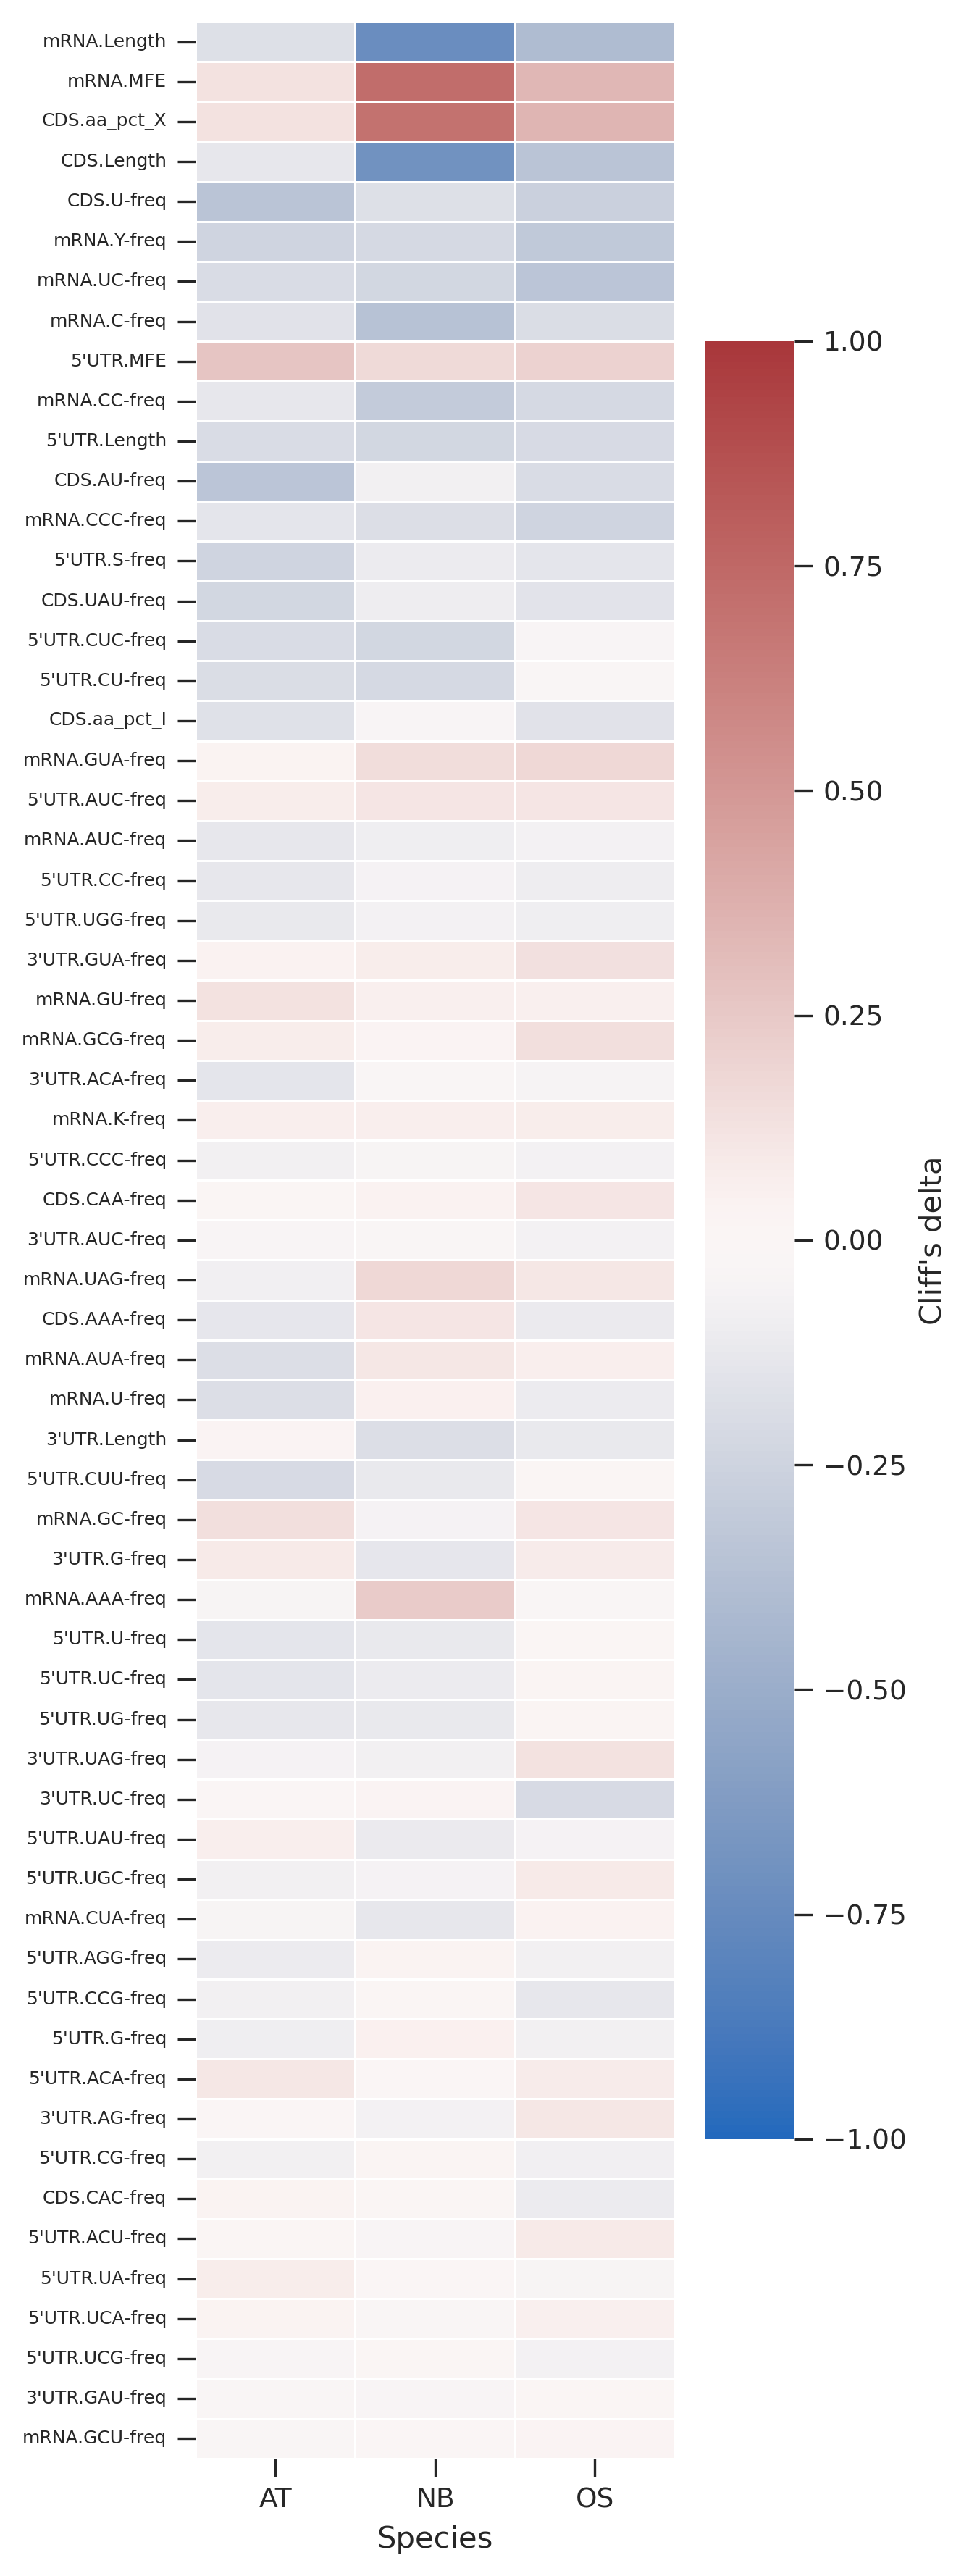

In [37]:
# ============================================
# Cross-species Top vs Bottom PR effect summary
# ============================================

effect_matrix_df = (
    top_bottom_stats_df
    .pivot(index="Feature", columns="Species", values="Cliff_delta")
    .reindex(columns=["AT", "NB", "OS"])
)

fdr_matrix_df = (
    top_bottom_stats_df
    .pivot(index="Feature", columns="Species", values="FDR")
    .reindex(columns=["AT", "NB", "OS"])
)

effect_summary_df = feature_metadata_df.copy()
effect_summary_df["AT"] = effect_summary_df["Feature"].map(effect_matrix_df["AT"])
effect_summary_df["NB"] = effect_summary_df["Feature"].map(effect_matrix_df["NB"])
effect_summary_df["OS"] = effect_summary_df["Feature"].map(effect_matrix_df["OS"])

effect_summary_df["Mean_delta"] = effect_summary_df[["AT", "NB", "OS"]].mean(axis=1)
effect_summary_df["Mean_abs_delta"] = effect_summary_df[["AT", "NB", "OS"]].abs().mean(axis=1)
effect_summary_df["Min_abs_delta"] = effect_summary_df[["AT", "NB", "OS"]].abs().min(axis=1)

effect_summary_df["Same_direction"] = (
    ((effect_summary_df[["AT", "NB", "OS"]] > 0).all(axis=1)) |
    ((effect_summary_df[["AT", "NB", "OS"]] < 0).all(axis=1))
)

effect_summary_df["FDR_all"] = (
    (fdr_matrix_df.loc[effect_summary_df["Feature"], ["AT", "NB", "OS"]].to_numpy() < 0.05)
    .all(axis=1)
)

effect_summary_df = (
    effect_summary_df
    .sort_values(["Same_direction", "Mean_abs_delta"], ascending=[False, False])
    .reset_index(drop=True)
)

print("Cross-species effect summary")
print("----------------------------")
display(effect_summary_df.head(20))

print("\nSame direction in all species :", effect_summary_df["Same_direction"].sum())
print("FDR < 0.05 in all species    :", effect_summary_df["FDR_all"].sum())
print(
    "Same direction + FDR all    :",
    (effect_summary_df["Same_direction"] & effect_summary_df["FDR_all"]).sum(),
)

# --------------------------------------------
# Cliff's delta heatmap
# --------------------------------------------

plot_order = effect_summary_df["Feature"].tolist()
plot_matrix = effect_matrix_df.loc[plot_order, ["AT", "NB", "OS"]]

fig, ax = make_fig(w=4.5, h=12)

sns.heatmap(
    plot_matrix,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.25,
    linecolor="white",
    cbar_kws={"label": "Cliff's delta"},
    ax=ax,
)

format_axis(ax, xlabel="Species", ylabel="")
ax.tick_params(axis="x", labelrotation=0)
ax.tick_params(axis="y", labelrotation=0, labelsize=6)

plt.tight_layout()
plt.show()

Top conserved candidate features


,Feature,Region,Feature_type,AT,NB,OS,Mean_delta,Mean_abs_delta,Min_abs_delta
0,mRNA.Length,mRNA,Length,-0.177480,-0.728612,-0.399452,-0.435181,0.435181,0.177480
1,mRNA.MFE,mRNA,RNA_structure_MFE,0.131843,0.720378,0.340407,0.397543,0.397543,0.131843
2,CDS.aa_pct_X,CDS,Amino_acid_composition,0.131967,0.702920,0.348626,0.394504,0.394504,0.131967
3,CDS.Length,CDS,Length,-0.131967,-0.702920,-0.348626,-0.394504,0.394504,0.131967
4,CDS.U-freq,CDS,Nucleotide_kmer_freq,-0.349315,-0.173726,-0.270839,-0.264627,0.264627,0.173726
5,mRNA.Y-freq,mRNA,Nucleotide_kmer_freq,-0.245841,-0.217120,-0.315405,-0.259455,0.259455,0.217120
6,mRNA.UC-freq,mRNA,Nucleotide_kmer_freq,-0.198695,-0.227006,-0.342551,-0.256084,0.256084,0.198695
7,mRNA.C-freq,mRNA,Nucleotide_kmer_freq,-0.162410,-0.366868,-0.188936,-0.239405,0.239405,0.162410
8,5'UTR.MFE,5'UTR,RNA_structure_MFE,0.266725,0.169141,0.208918,0.214928,0.214928,0.169141
9,mRNA.CC-freq,mRNA,Nucleotide_kmer_freq,-0.132554,-0.297827,-0.212195,-0.214192,0.214192,0.132554


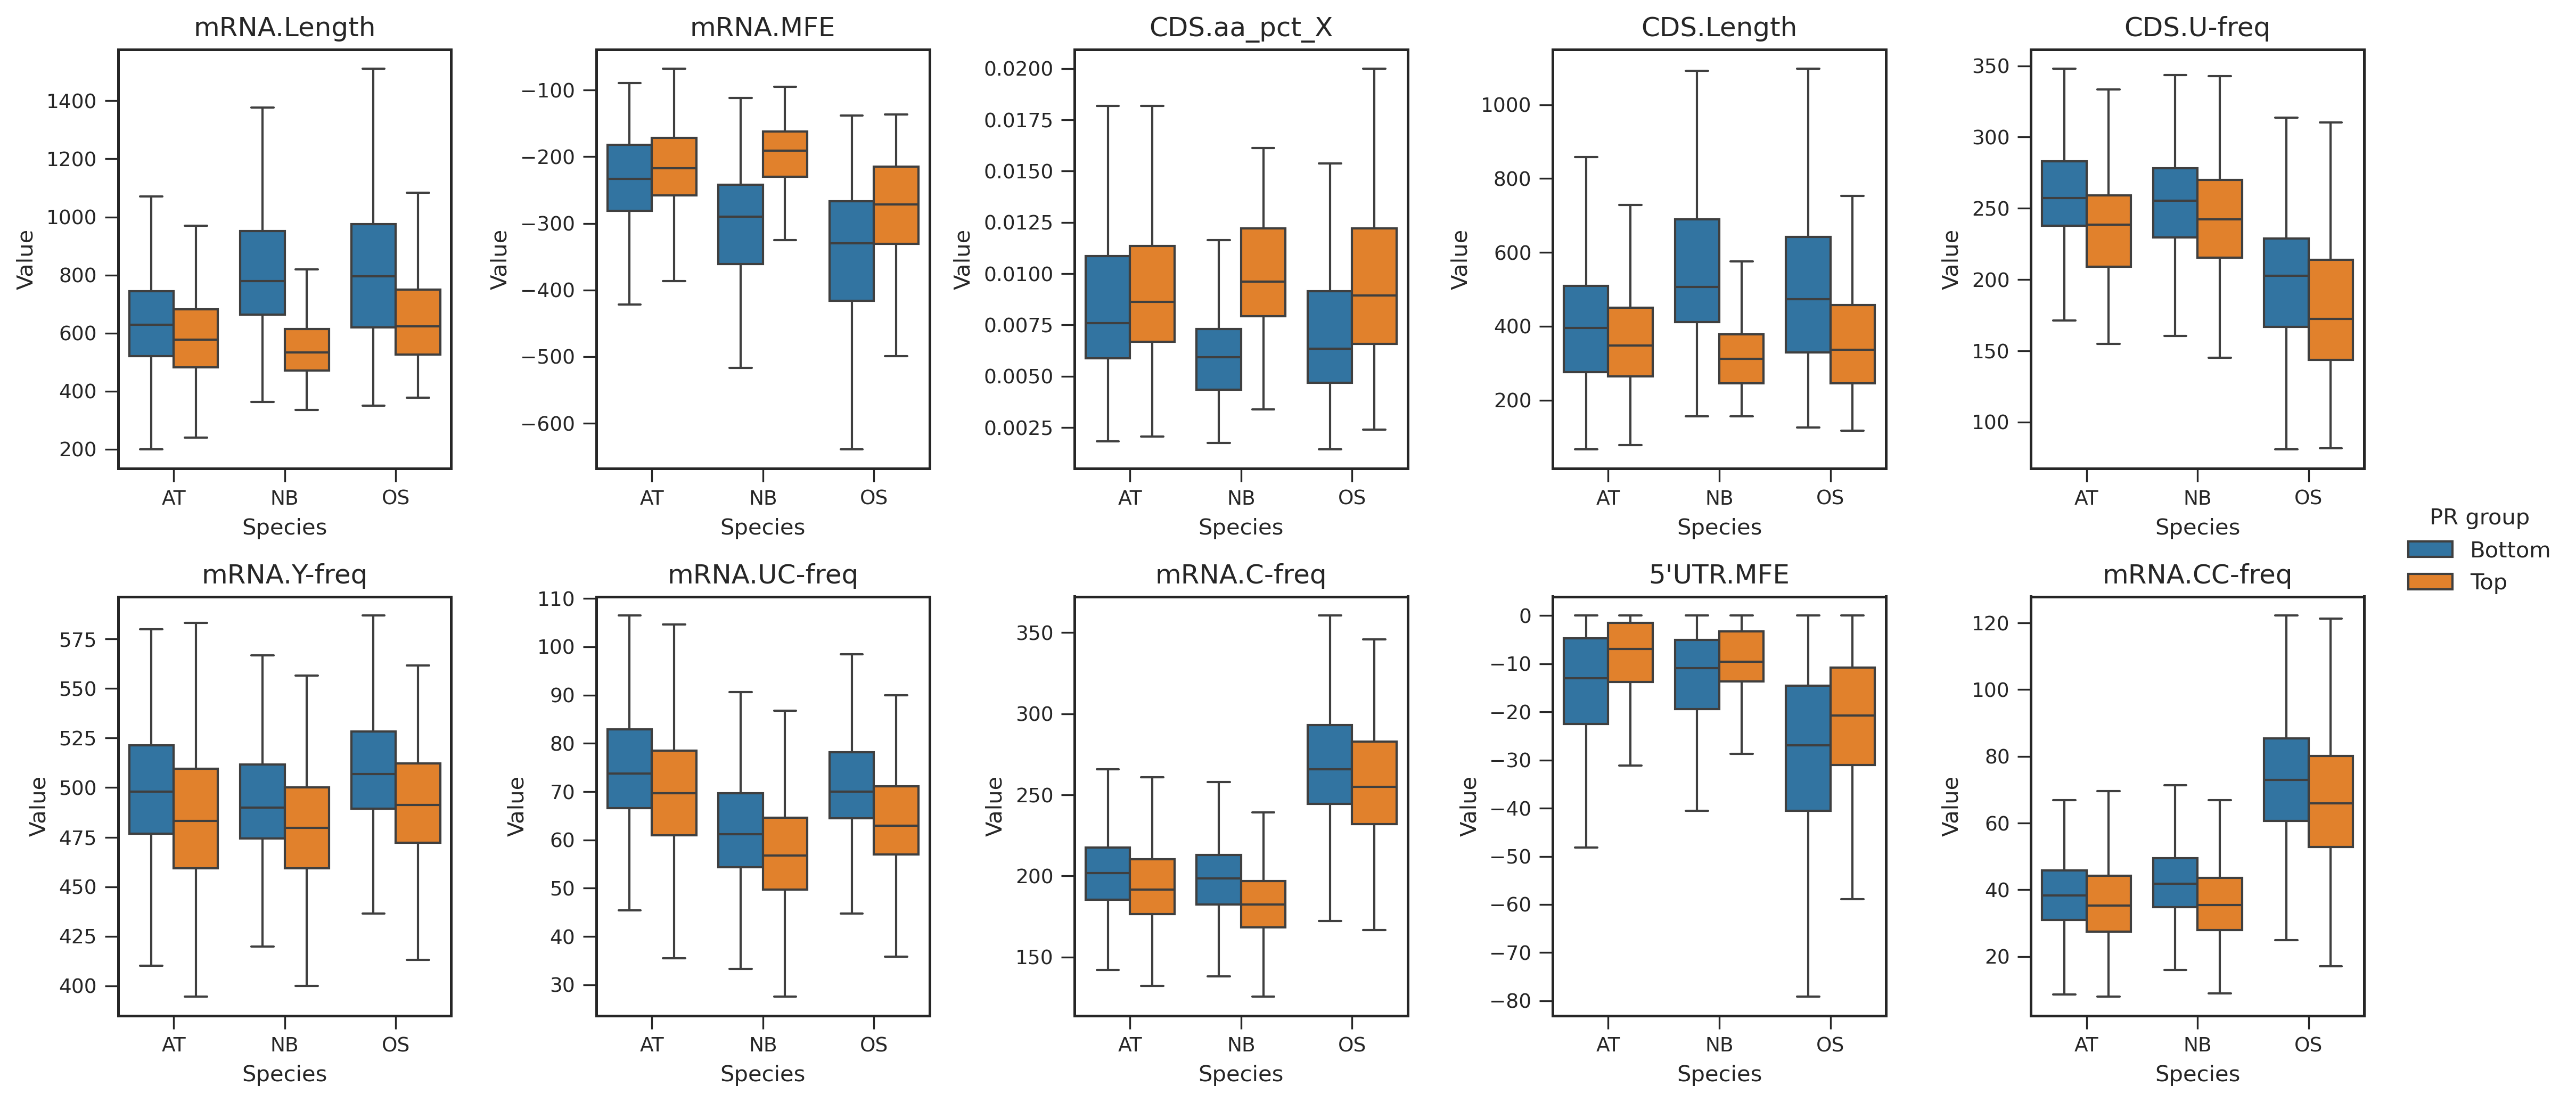

In [38]:
# ============================================
# Strongest conserved Top vs Bottom PR effects
# ============================================

top_conserved_df = (
    effect_summary_df[
        effect_summary_df["Same_direction"] &
        effect_summary_df["FDR_all"]
    ]
    .sort_values("Mean_abs_delta", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_conserved_features = top_conserved_df["Feature"].tolist()

print("Top conserved candidate features")
display(
    top_conserved_df[
        ["Feature", "Region", "Feature_type", "AT", "NB", "OS",
         "Mean_delta", "Mean_abs_delta", "Min_abs_delta"]
    ]
)

# --------------------------------------------
# Raw-value Top vs Bottom distributions
# --------------------------------------------

fig, axes = plt.subplots(
    2, 5,
    figsize=(15, 7),
    dpi=_PLOT_CFG["dpi"],
)

axes = axes.ravel()

for ax, feature in zip(axes, top_conserved_features):

    plot_df = candidate_group_df[
        ["Species", "PR_group", feature]
    ].rename(columns={feature: "Value"})

    sns.boxplot(
        data=plot_df,
        x="Species",
        y="Value",
        hue="PR_group",
        order=["AT", "NB", "OS"],
        hue_order=["Bottom", "Top"],
        showfliers=False,
        ax=ax,
    )

    ax.set_title(feature)

    format_axis(
        ax,
        xlabel="Species",
        ylabel="Value",
    )

    if ax.get_legend() is not None:
        ax.get_legend().remove()

# --------------------------------------------
# Shared legend
# --------------------------------------------

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="PR group",
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.00, 0.5),
)

plt.tight_layout()
plt.show()